In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression , LogisticRegression
from sklearn.preprocessing import StandardScaler , MinMaxScaler , RobustScaler ,  PowerTransformer
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import f1_score , recall_score , precision_score , roc_auc_score , classification_report , mean_absolute_error , mean_squared_error , r2_score 
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier , CatBoostRegressor

# NOTE: LinearRegression / LogisticRegression, the scalers (StandardScaler/MinMaxScaler/RobustScaler/PowerTransformer),
# GridSearchCV and the metrics functions are not used yet in this notebook - it only covers EDA and data
# preparation. They are imported now because they will be needed in the upcoming model-training/evaluation notebook.

In [2]:
pd.set_option('display.max_columns', None)   
pd.set_option('display.max_rows', None)      
pd.set_option('display.width', None)    

## reading data


In [3]:
df = pd.read_csv("Synthetic-Solar-Farm-Stream-No-Repair.csv")

In [4]:
df.shape

(525600, 25)

In [5]:
df.head()

,time,device,active_power,irradiance,clear_sky_irradiance,ambient_temp,module_temp,inverter_temp,dc_voltage,dc_current,ac_voltage,ac_current,performance_ratio,cloud_cover,sun_elevation,sun_azimuth,day_length_hours,fault_soiling,fault_inverter_overheat,fault_tracker_stuck,fault_dc_string_outage,is_faulted,fault_labels,downtime_start_time,fault_severity
0,2025-01-01 00:00:00,PV000,0.0,0.0,4.88,2.20,1.90,1.99,0.0,0.0,0.0,0.0,0.0,0.424,-78.04,356.77,9.69,0,0,0,0,0,healthy,NaT,none
1,2025-01-01 00:00:00,PV001,0.0,0.0,1.29,2.43,3.65,3.02,0.0,0.0,0.0,0.0,0.0,0.386,-78.04,356.77,9.69,0,0,0,0,0,healthy,2025-05-01 00:05:00,none
2,2025-01-01 00:00:00,PV002,0.0,0.0,1.08,2.08,3.60,2.81,0.0,0.0,0.0,0.0,0.0,0.373,-78.04,356.77,9.69,0,0,0,0,0,healthy,2025-06-21 13:30:00,none
3,2025-01-01 00:00:00,PV003,0.0,0.0,0.00,2.07,2.97,2.50,0.0,0.0,0.0,0.0,0.0,0.397,-78.04,356.77,9.69,0,0,0,0,0,healthy,2025-03-27 00:00:00,none
4,2025-01-01 00:00:00,PV004,0.0,0.0,0.15,2.06,0.81,1.41,0.0,0.0,0.0,0.0,0.0,0.376,-78.04,356.77,9.69,0,0,0,0,0,healthy,2025-10-23 00:00:00,none


In [6]:
df.tail()

,time,device,active_power,irradiance,clear_sky_irradiance,ambient_temp,module_temp,inverter_temp,dc_voltage,dc_current,ac_voltage,ac_current,performance_ratio,cloud_cover,sun_elevation,sun_azimuth,day_length_hours,fault_soiling,fault_inverter_overheat,fault_tracker_stuck,fault_dc_string_outage,is_faulted,fault_labels,downtime_start_time,fault_severity
525595,2025-12-31 23:55:00,PV000,0.0,0.0,6.29,0.60,0.02,0.30,0.0,0.0,0.0,0.0,0.0,0.190,-78.02,351.72,9.68,0,0,0,0,0,healthy,NaT,none
525596,2025-12-31 23:55:00,PV001,0.0,0.0,0.00,0.31,1.33,0.81,0.0,0.0,0.0,0.0,0.0,0.141,-78.02,351.72,9.68,0,0,0,0,0,healthy,2025-05-01 00:05:00,none
525597,2025-12-31 23:55:00,PV002,0.0,0.0,2.47,0.54,1.96,1.19,0.0,0.0,0.0,0.0,0.0,0.162,-78.02,351.72,9.68,0,0,0,0,0,healthy,2025-06-21 13:30:00,none
525598,2025-12-31 23:55:00,PV003,0.0,0.0,0.00,0.30,1.01,0.65,0.0,0.0,0.0,0.0,0.0,0.158,-78.02,351.72,9.68,0,0,0,0,0,healthy,2025-03-27 00:00:00,none
525599,2025-12-31 23:55:00,PV004,0.0,0.0,0.00,0.26,-1.17,0.54,0.0,0.0,0.0,0.0,0.0,0.153,-78.02,351.72,9.68,0,0,0,1,1,dc_string_outage,2025-10-23 00:00:00,high


In [7]:
df.columns.tolist()

['time',
 'device',
 'active_power',
 'irradiance',
 'clear_sky_irradiance',
 'ambient_temp',
 'module_temp',
 'inverter_temp',
 'dc_voltage',
 'dc_current',
 'ac_voltage',
 'ac_current',
 'performance_ratio',
 'cloud_cover',
 'sun_elevation',
 'sun_azimuth',
 'day_length_hours',
 'fault_soiling',
 'fault_inverter_overheat',
 'fault_tracker_stuck',
 'fault_dc_string_outage',
 'is_faulted',
 'fault_labels',
 'downtime_start_time',
 'fault_severity']

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   time                     525600 non-null  str    
 1   device                   525600 non-null  str    
 2   active_power             525600 non-null  float64
 3   irradiance               525600 non-null  float64
 4   clear_sky_irradiance     525600 non-null  float64
 5   ambient_temp             525600 non-null  float64
 6   module_temp              525600 non-null  float64
 7   inverter_temp            525600 non-null  float64
 8   dc_voltage               525600 non-null  float64
 9   dc_current               525600 non-null  float64
 10  ac_voltage               525600 non-null  float64
 11  ac_current               525600 non-null  float64
 12  performance_ratio        525600 non-null  float64
 13  cloud_cover              525600 non-null  float64
 14  sun_elevation  

Data Quality

In [9]:
df.isnull().sum()

time                       0
device                     0
active_power               0
irradiance                 0
clear_sky_irradiance       0
ambient_temp               0
module_temp                0
inverter_temp              0
dc_voltage                 0
dc_current                 0
ac_voltage                 0
ac_current                 0
performance_ratio          0
cloud_cover                0
sun_elevation              0
sun_azimuth                0
day_length_hours           0
fault_soiling              0
fault_inverter_overheat    0
fault_tracker_stuck        0
fault_dc_string_outage     0
is_faulted                 0
fault_labels               0
downtime_start_time        0
fault_severity             0
dtype: int64

In [10]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing.sort_values("Missing Count", ascending=False)

# To explore the percentage  ---> (fill,drop)

,Missing Count,Missing Percentage
time,0,0.0
device,0,0.0
active_power,0,0.0
irradiance,0,0.0
clear_sky_irradiance,0,0.0
ambient_temp,0,0.0
module_temp,0,0.0
inverter_temp,0,0.0
dc_voltage,0,0.0
dc_current,0,0.0


In [11]:
df.duplicated().sum()

np.int64(0)

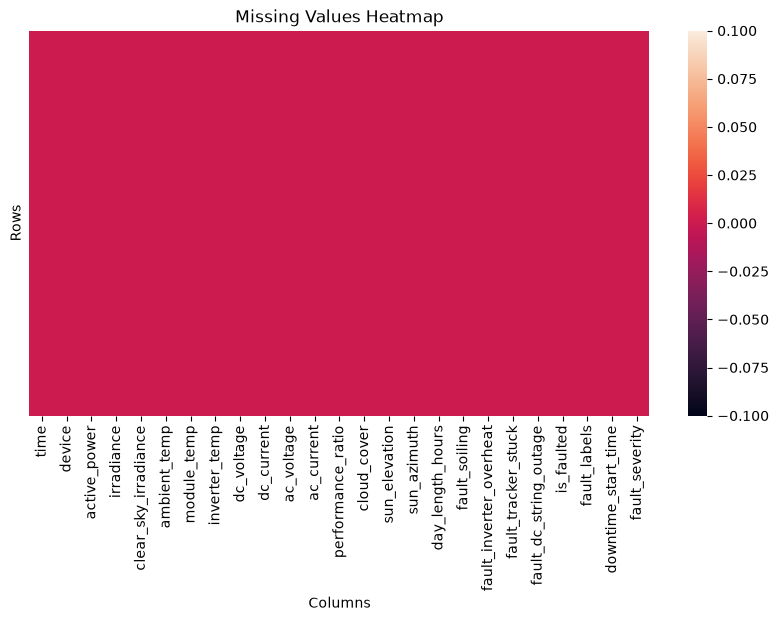

In [12]:
plt.figure(figsize=(10,5))
plt.title("Missing Values Heatmap")
sns.heatmap(df.isnull(),yticklabels=False)
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

Target analysis

In [13]:
df["is_faulted"].value_counts()

is_faulted
0    418320
1    107280
Name: count, dtype: int64

In [14]:
df["is_faulted"].value_counts(normalize=True) * 100

is_faulted
0    79.589041
1    20.410959
Name: proportion, dtype: float64

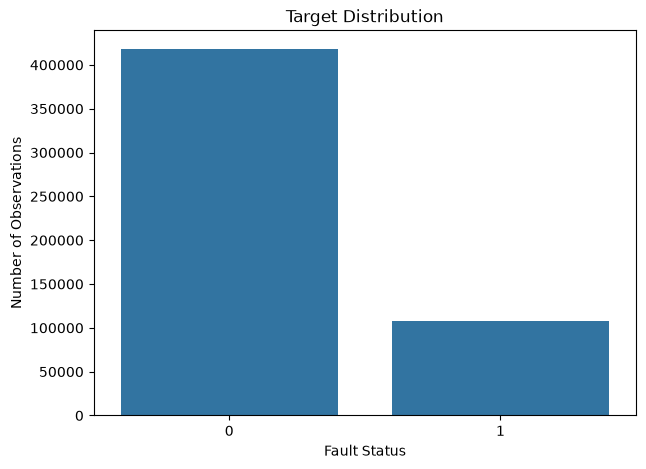

In [15]:
plt.figure(figsize=(7, 5))
plt.title("Target Distribution")
sns.countplot(data=df,x="is_faulted")
plt.xlabel("Fault Status")
plt.ylabel("Number of Observations")

plt.show()
# To see the diff. of classes VS observations ---> visual
# 0 ---> Noraml , 1 ---> Faulted

## Device profile

In [16]:
device_fault_ratio = df.groupby("device")["is_faulted"].mean() * 100
device_fault_ratio

device
PV000     0.000000
PV001    43.834665
PV002     0.526065
PV003    38.515982
PV004    19.178082
Name: is_faulted, dtype: float64

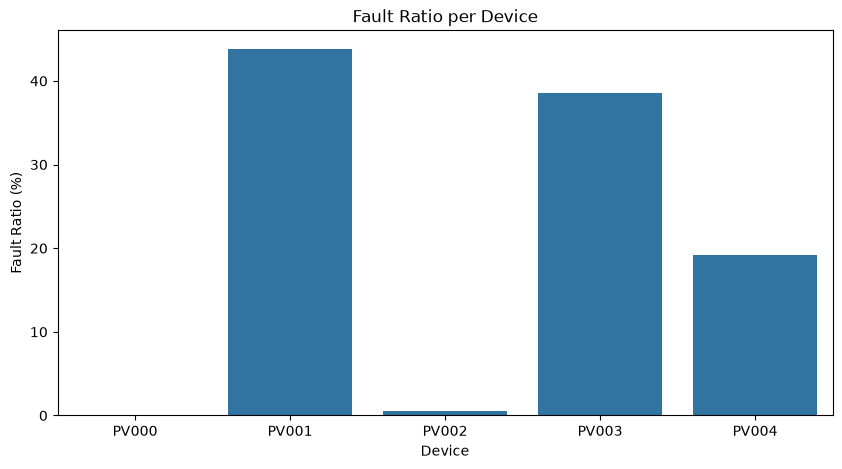

In [17]:
plt.figure(figsize=(10, 5))
plt.title("Fault Ratio per Device")
sns.barplot(x=device_fault_ratio.index, y=device_fault_ratio.values)
plt.xlabel("Device")
plt.ylabel("Fault Ratio (%)")
plt.show()

In [18]:
device_fault_types = pd.crosstab(df["device"], df["fault_labels"])
device_fault_types

fault_labels,dc_string_outage,dc_string_outage|downtime,downtime,healthy,inverter_overheat,soiling,tracker_stuck
device,,,,,,,
PV000,0,0,0,105120,0,0,0
PV001,0,0,0,59041,0,46079,0
PV002,0,0,33,104567,520,0,0
PV003,0,0,168,64632,0,0,40320
PV004,20106,54,0,84960,0,0,0


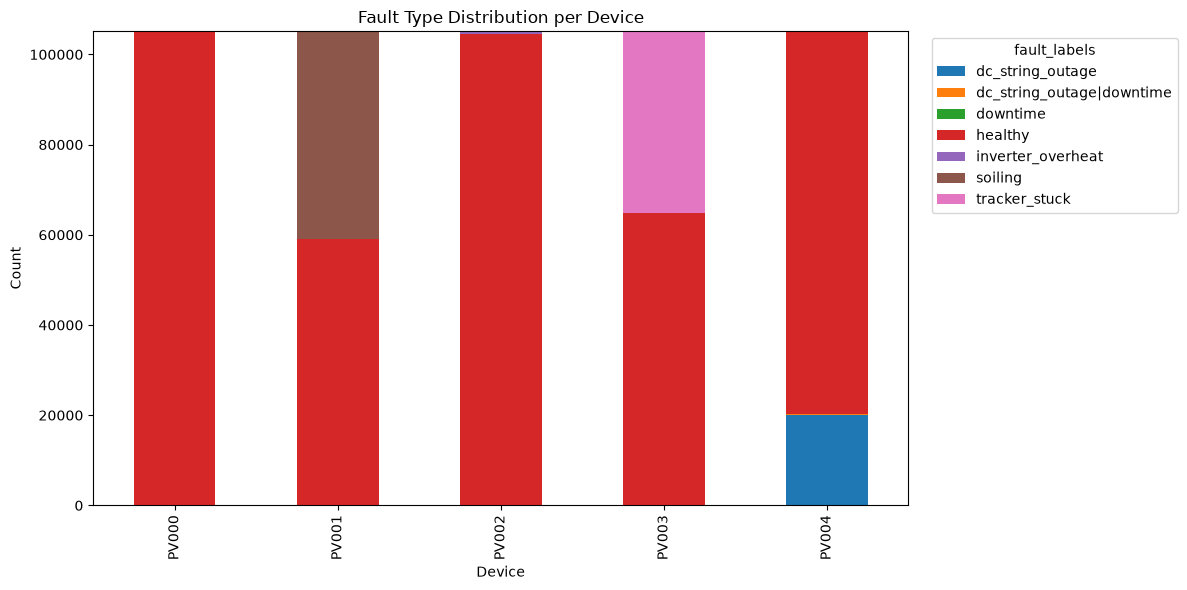

In [19]:
device_fault_types.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)
plt.title("Fault Type Distribution per Device")
plt.xlabel("Device")
plt.ylabel("Count")
plt.legend(title="fault_labels", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [20]:
device_power = df.groupby("device")["active_power"].mean()
device_power

device
PV000     999.171325
PV001     939.780527
PV002    1004.772148
PV003     878.718844
PV004     866.535098
Name: active_power, dtype: float64

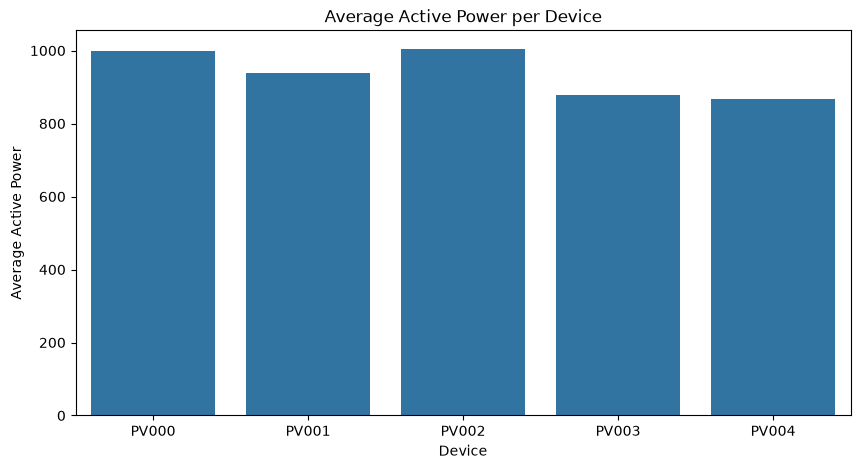

In [21]:
plt.figure(figsize=(10, 5))
plt.title("Average Active Power per Device")
sns.barplot(x=device_power.index, y=device_power.values)
plt.xlabel("Device")
plt.ylabel("Average Active Power")
plt.show()

In [22]:
device_pr = df.groupby("device")["performance_ratio"].mean()
device_pr

device
PV000    0.394768
PV001    0.377038
PV002    0.398142
PV003    0.338823
PV004    0.338832
Name: performance_ratio, dtype: float64

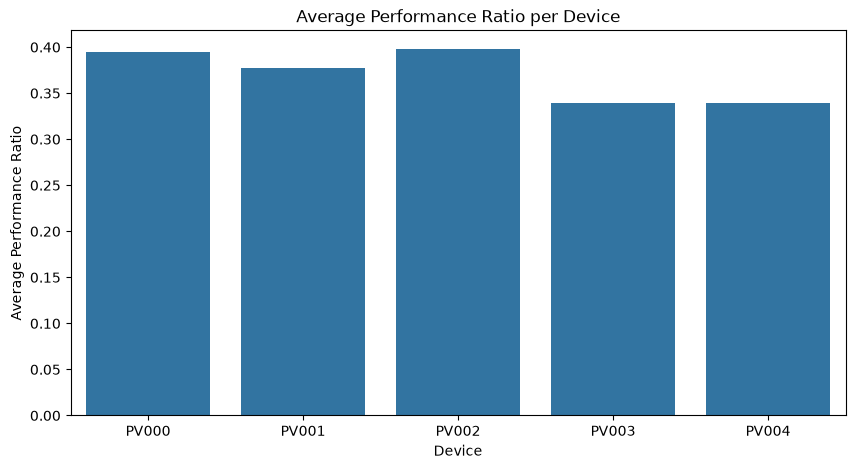

In [23]:
plt.figure(figsize=(10, 5))
plt.title("Average Performance Ratio per Device")
sns.barplot(x=device_pr.index, y=device_pr.values)
plt.xlabel("Device")
plt.ylabel("Average Performance Ratio")
plt.show()

Numerical Features Analysis

In [24]:
df.select_dtypes(include=np.number).columns
# To know the num features

Index(['active_power', 'irradiance', 'clear_sky_irradiance', 'ambient_temp',
       'module_temp', 'inverter_temp', 'dc_voltage', 'dc_current',
       'ac_voltage', 'ac_current', 'performance_ratio', 'cloud_cover',
       'sun_elevation', 'sun_azimuth', 'day_length_hours', 'fault_soiling',
       'fault_inverter_overheat', 'fault_tracker_stuck',
       'fault_dc_string_outage', 'is_faulted'],
      dtype='str')

In [25]:
numeric_features = df.select_dtypes(
    include=np.number
).columns.drop("is_faulted")

numeric_features
# drop the target 

Index(['active_power', 'irradiance', 'clear_sky_irradiance', 'ambient_temp',
       'module_temp', 'inverter_temp', 'dc_voltage', 'dc_current',
       'ac_voltage', 'ac_current', 'performance_ratio', 'cloud_cover',
       'sun_elevation', 'sun_azimuth', 'day_length_hours', 'fault_soiling',
       'fault_inverter_overheat', 'fault_tracker_stuck',
       'fault_dc_string_outage'],
      dtype='str')

In [26]:
df[numeric_features].describe()
# I don't want the target

,active_power,irradiance,clear_sky_irradiance,ambient_temp,module_temp,inverter_temp,dc_voltage,dc_current,ac_voltage,ac_current,performance_ratio,cloud_cover,sun_elevation,sun_azimuth,day_length_hours,fault_soiling,fault_inverter_overheat,fault_tracker_stuck,fault_dc_string_outage
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000
mean,937.795588,229.056011,308.992016,17.971951,25.090230,28.688898,404.690521,1.237591,198.856996,1.441851,0.369521,0.345216,0.288488,179.999155,12.039205,0.087669,0.000989,0.076712,0.038356
std,1201.651000,295.152747,392.665318,8.657496,15.225925,19.479762,406.559276,1.590191,200.003891,1.836076,0.383538,0.173170,38.598312,100.104030,1.622983,0.282814,0.031438,0.266135,0.192055
min,0.000000,0.000000,0.000000,-1.220000,-2.380000,-1.760000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-78.420000,0.000000,9.650000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,11.020000,12.760000,12.810000,0.000000,0.000000,0.000000,0.000000,0.000000,0.217000,-31.210000,89.630000,10.470000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,9.520000,18.010000,23.250000,24.040000,0.000000,0.000000,0.000000,0.000000,0.000000,0.341000,0.230000,179.995000,12.070000,0.000000,0.000000,0.000000,0.000000
75%,1894.182500,462.870000,628.172500,24.970000,34.750000,41.820000,813.550000,2.479000,399.990000,2.924000,0.753400,0.469000,31.580000,270.350000,13.610000,0.000000,0.000000,0.000000,0.000000
max,4400.000000,1188.630000,1219.760000,37.120000,70.090000,92.540000,835.840000,5.718000,408.610000,6.435000,1.020000,0.967000,78.450000,359.990000,14.360000,1.000000,1.000000,1.000000,1.000000


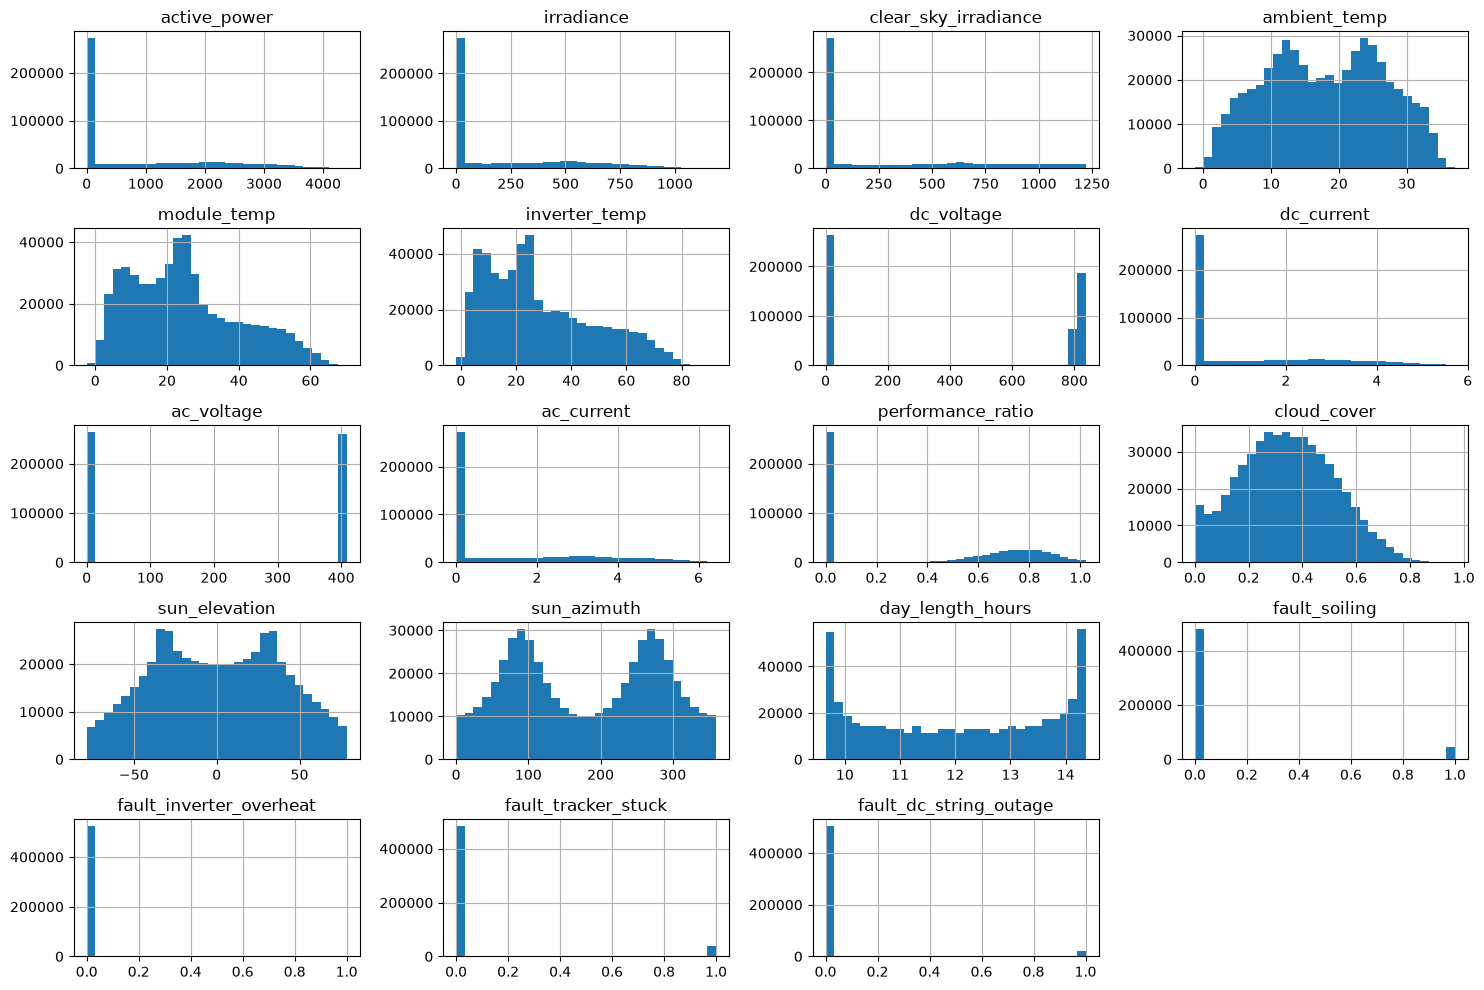

In [27]:
df[numeric_features].hist(
    bins=30,
    figsize=(15, 10)
)

plt.tight_layout()
plt.show()

In [28]:
skewness = df[numeric_features].skew().sort_values(ascending=False)

print(skewness)

fault_inverter_overheat    31.745487
fault_dc_string_outage      4.807437
fault_tracker_stuck         3.181015
fault_soiling               2.915929
irradiance                  0.969780
dc_current                  0.956697
active_power                0.943011
ac_current                  0.917314
clear_sky_irradiance        0.893757
inverter_temp               0.679952
module_temp                 0.551877
performance_ratio           0.180151
cloud_cover                 0.146748
ac_voltage                  0.011592
dc_voltage                  0.009765
sun_elevation               0.001773
sun_azimuth                -0.000002
ambient_temp               -0.012573
day_length_hours           -0.034151
dtype: float64


See the Outliers

In [29]:
continuous_features = [
    col for col in numeric_features
    if df[col].nunique() > 2
]

continuous_features
#except the features which have 2 values (0/1)

['active_power',
 'irradiance',
 'clear_sky_irradiance',
 'ambient_temp',
 'module_temp',
 'inverter_temp',
 'dc_voltage',
 'dc_current',
 'ac_voltage',
 'ac_current',
 'performance_ratio',
 'cloud_cover',
 'sun_elevation',
 'sun_azimuth',
 'day_length_hours']

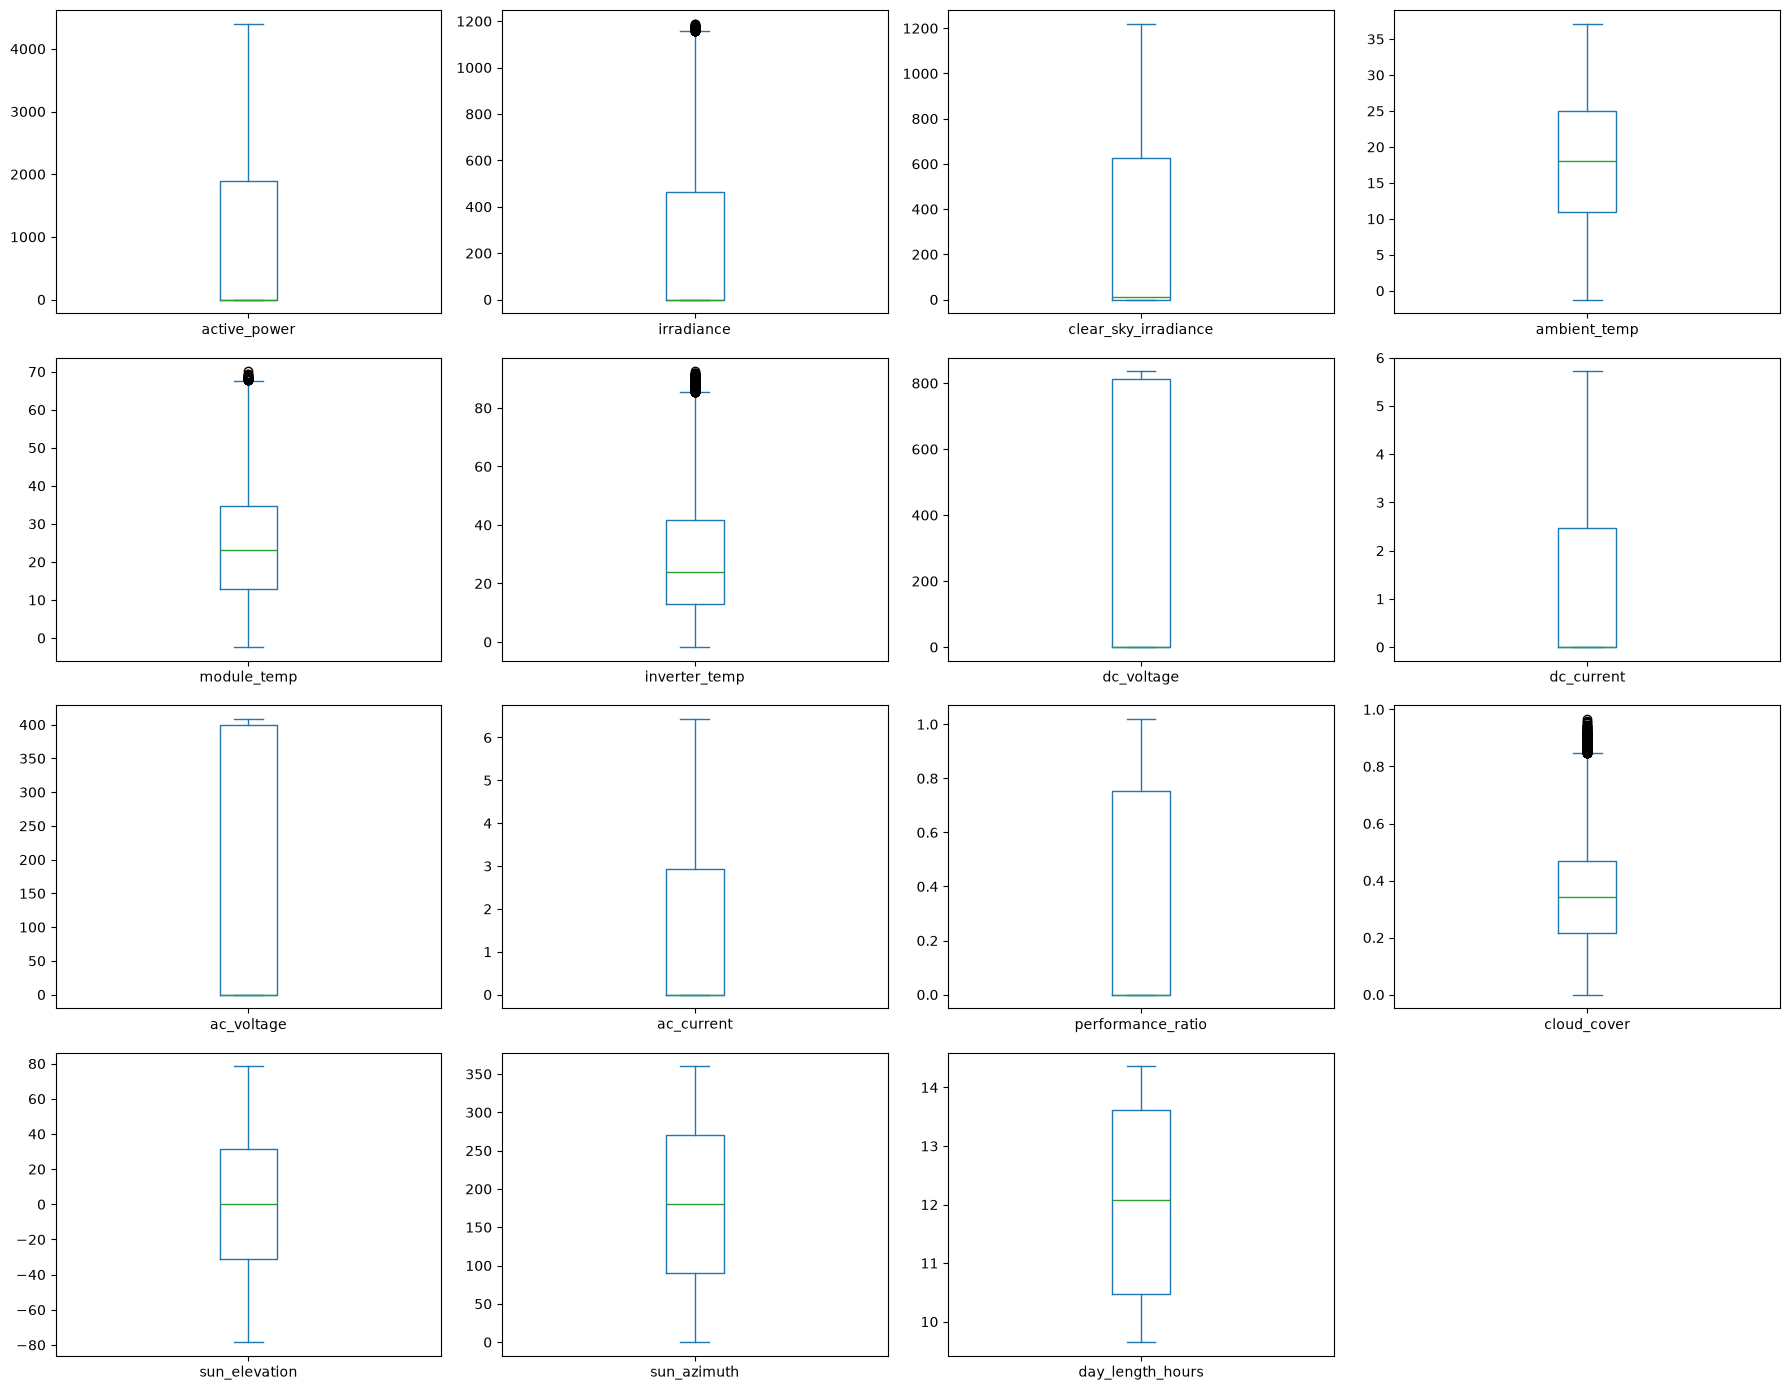

In [30]:
df[continuous_features].plot(
    kind="box",
    subplots=True,
    layout=(4, 4),
    figsize=(18, 14)
)

plt.tight_layout()
plt.show()

Explore Outliers

In [31]:
def check_outliers(data, col, symmetric=True):
    """Boxplot + IQR-based outlier summary for one numeric column.

    symmetric=True checks both tails (lower and upper bound).
    symmetric=False checks the upper tail only (for columns where only
    unusually HIGH values are meaningful outliers, e.g. irradiance).

    Returns the bounds and outlier count so results can be inspected later,
    instead of just printing them.
    """
    plt.figure(figsize=(14, 5))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}", fontsize=18)
    plt.xlabel(col, fontsize=14)
    plt.tight_layout()
    plt.show()

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    if symmetric:
        mask = (data[col] < lower_bound) | (data[col] > upper_bound)
    else:
        mask = data[col] > upper_bound
    outliers = data[col][mask]

    print(f"--- {col} ---")
    print("Q1:", Q1, "| Q3:", Q3, "| IQR:", IQR)
    print("Lower bound:", lower_bound, "| Upper bound:", upper_bound)
    print("Number of outliers:", len(outliers))
    if len(outliers) > 0:
        print("Min outlier:", outliers.min(), "| Max outlier:", outliers.max())
    print()

    return {"lower_bound": lower_bound, "upper_bound": upper_bound, "n_outliers": len(outliers)}


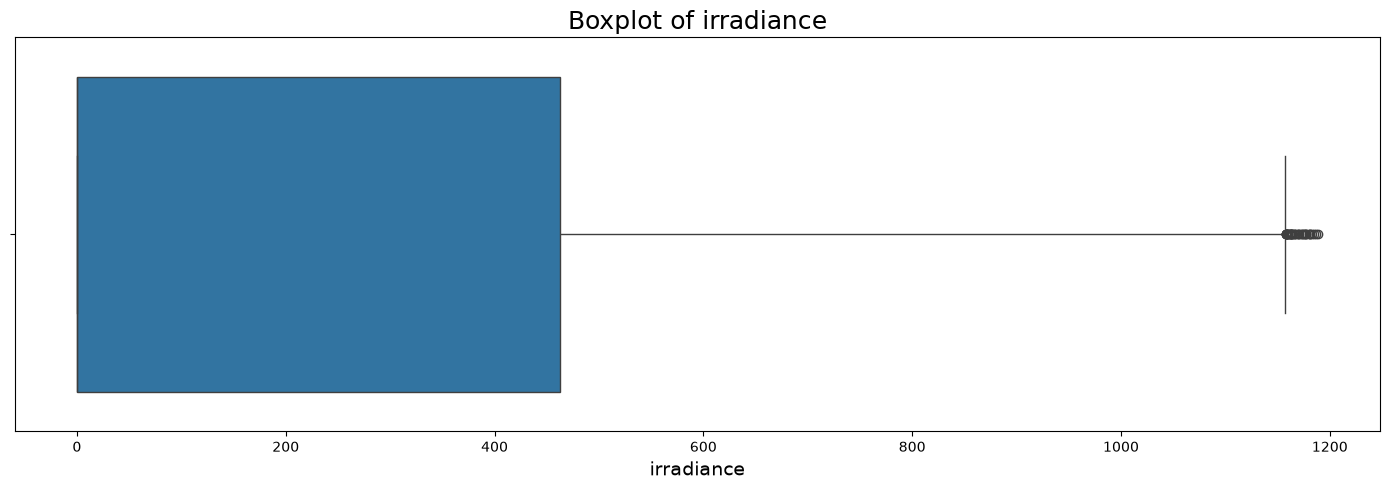

--- irradiance ---
Q1: 0.0 | Q3: 462.87 | IQR: 462.87
Lower bound: -694.3050000000001 | Upper bound: 1157.1750000000002
Number of outliers: 38
Min outlier: 1157.61 | Max outlier: 1188.63



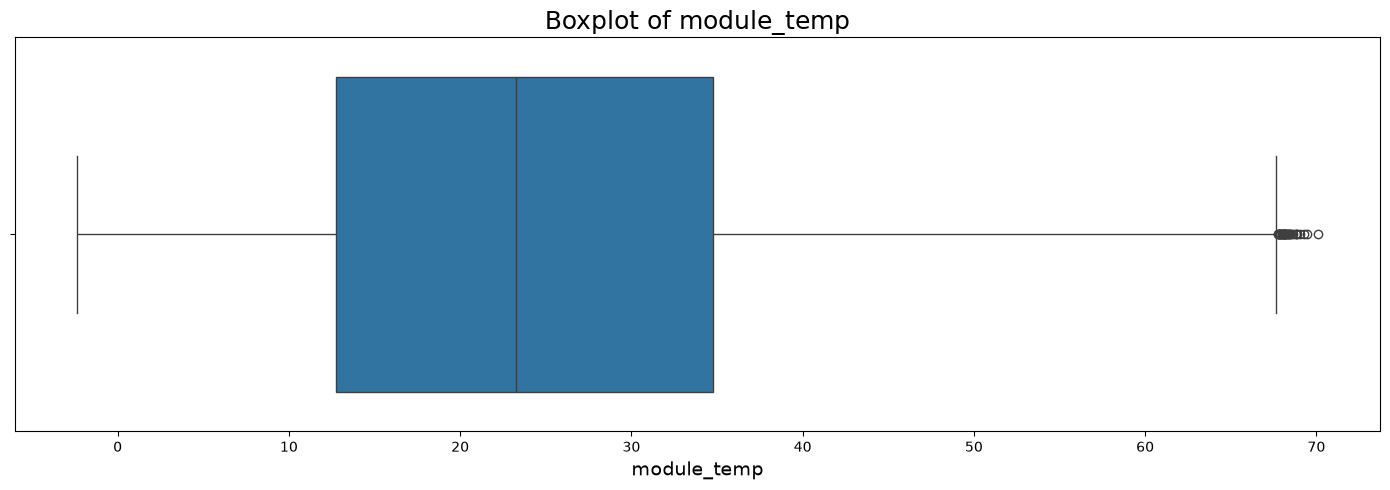

--- module_temp ---
Q1: 12.76 | Q3: 34.75 | IQR: 21.990000000000002
Lower bound: -20.225 | Upper bound: 67.735
Number of outliers: 34
Min outlier: 67.74 | Max outlier: 70.09



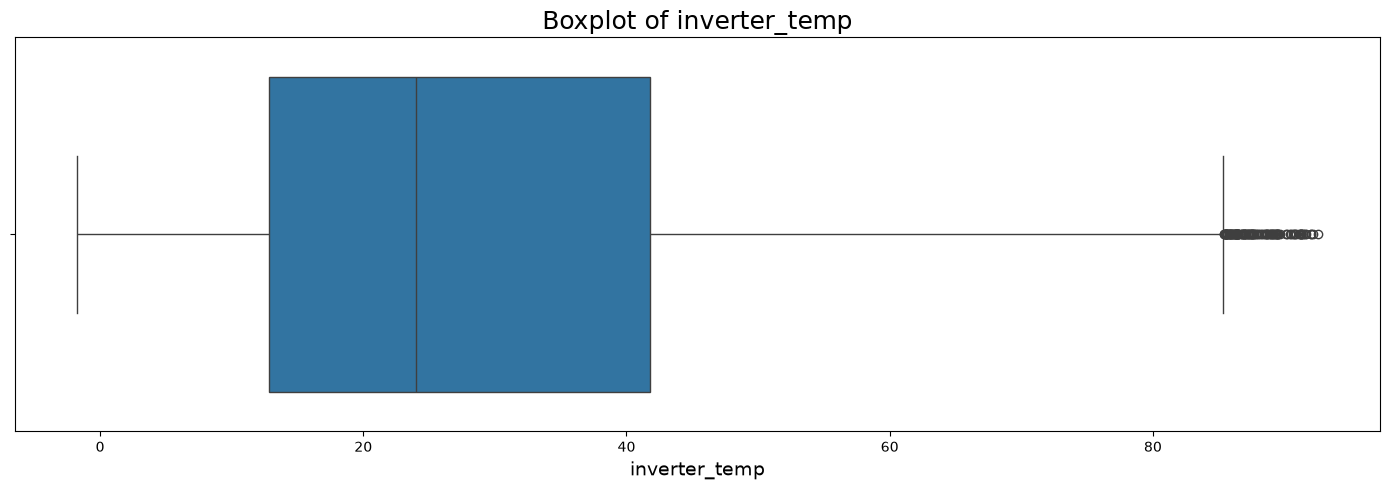

--- inverter_temp ---
Q1: 12.81 | Q3: 41.82 | IQR: 29.009999999999998
Lower bound: -30.705 | Upper bound: 85.33500000000001
Number of outliers: 118
Min outlier: 85.39 | Max outlier: 92.54



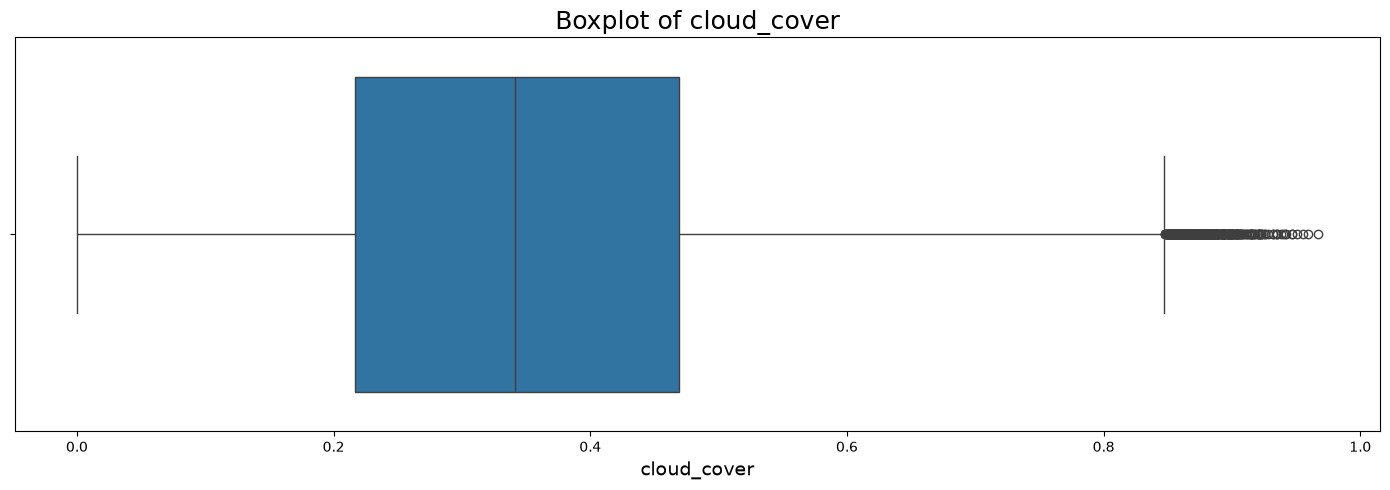

--- cloud_cover ---
Q1: 0.217 | Q3: 0.469 | IQR: 0.252
Lower bound: -0.161 | Upper bound: 0.847
Number of outliers: 432
Min outlier: 0.848 | Max outlier: 0.967



{'irradiance': {'lower_bound': np.float64(-694.3050000000001),
  'upper_bound': np.float64(1157.1750000000002),
  'n_outliers': 38},
 'module_temp': {'lower_bound': np.float64(-20.225),
  'upper_bound': np.float64(67.735),
  'n_outliers': 34},
 'inverter_temp': {'lower_bound': np.float64(-30.705),
  'upper_bound': np.float64(85.33500000000001),
  'n_outliers': 118},
 'cloud_cover': {'lower_bound': np.float64(-0.161),
  'upper_bound': np.float64(0.847),
  'n_outliers': 432}}

In [32]:
# Same IQR check for the four continuous features that showed outliers in the
# boxplot grid above. Decision (same for all four, kept from the original
# analysis): don't drop these outliers - unusually high irradiance / module
# temp / inverter temp / cloud cover values are plausible readings under
# normal operating conditions, not data errors.
outlier_summary = {}
outlier_summary["irradiance"] = check_outliers(df, "irradiance", symmetric=False)
outlier_summary["module_temp"] = check_outliers(df, "module_temp")
outlier_summary["inverter_temp"] = check_outliers(df, "inverter_temp")
outlier_summary["cloud_cover"] = check_outliers(df, "cloud_cover")

outlier_summary


Correlation Analysis

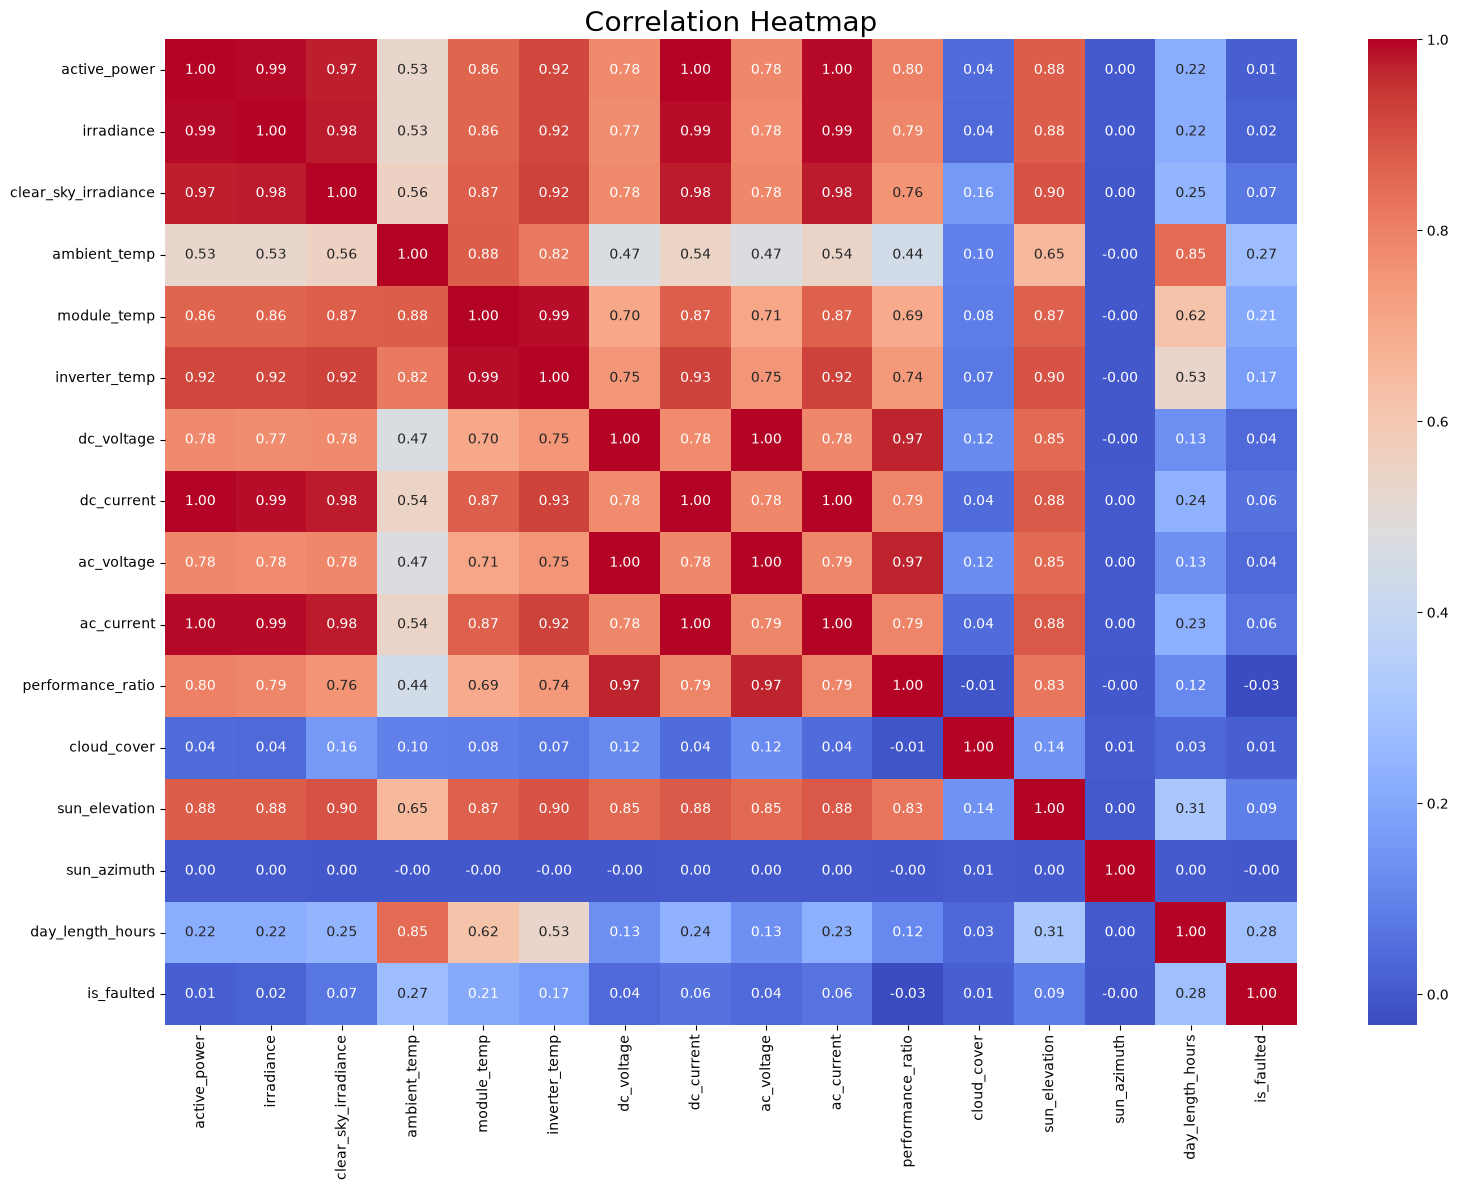

In [33]:
plt.figure(figsize=(16, 12))
plt.title("Correlation Heatmap", fontsize=20)
sns.heatmap(
    df[continuous_features + ["is_faulted"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.tight_layout()
plt.show()

## convert str to datetime and sorting 

In [34]:
df['downtime_start_time'] = pd.to_datetime(df['downtime_start_time'])
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')

In [35]:
df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month
df['day_of_week'] = df['time'].dt.dayofweek
df['is_daylight'] = df['hour'].between(6, 18).astype(int)
df = df.set_index('time')

## Time gaps check

In [36]:
time_series = df.index.to_series()
df["time_diff_min"] = time_series.groupby(df["device"]).diff().dt.total_seconds() / 60.0

In [37]:
expected_gap_min = df["time_diff_min"].mode()[0]

gaps = df[df["time_diff_min"] > expected_gap_min]
gaps_per_device = gaps.groupby("device").size()

print("Expected gap between readings (minutes):", expected_gap_min)
print("Total gaps found:", len(gaps))
gaps_per_device

Expected gap between readings (minutes): 5.0
Total gaps found: 0


Series([], dtype: int64)

In [38]:
df = df.drop(columns=["time_diff_min"])

## calculate downtime in min

In [39]:
df['downtime_duration_min'] = (df.index - df['downtime_start_time']).dt.total_seconds() / 60.0
df['downtime_duration_min'] = df['downtime_duration_min'].fillna(0).clip(lower=0)

df = df.drop(columns=['downtime_start_time'])

In [40]:
df.head()

,device,active_power,irradiance,clear_sky_irradiance,ambient_temp,module_temp,inverter_temp,dc_voltage,dc_current,ac_voltage,ac_current,performance_ratio,cloud_cover,sun_elevation,sun_azimuth,day_length_hours,fault_soiling,fault_inverter_overheat,fault_tracker_stuck,fault_dc_string_outage,is_faulted,fault_labels,fault_severity,hour,month,day_of_week,is_daylight,downtime_duration_min
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-01-01,PV000,0.0,0.0,4.88,2.20,1.90,1.99,0.0,0.0,0.0,0.0,0.0,0.424,-78.04,356.77,9.69,0,0,0,0,0,healthy,none,0,1,2,0,0.0
2025-01-01,PV001,0.0,0.0,1.29,2.43,3.65,3.02,0.0,0.0,0.0,0.0,0.0,0.386,-78.04,356.77,9.69,0,0,0,0,0,healthy,none,0,1,2,0,0.0
2025-01-01,PV002,0.0,0.0,1.08,2.08,3.60,2.81,0.0,0.0,0.0,0.0,0.0,0.373,-78.04,356.77,9.69,0,0,0,0,0,healthy,none,0,1,2,0,0.0
2025-01-01,PV003,0.0,0.0,0.00,2.07,2.97,2.50,0.0,0.0,0.0,0.0,0.0,0.397,-78.04,356.77,9.69,0,0,0,0,0,healthy,none,0,1,2,0,0.0
2025-01-01,PV004,0.0,0.0,0.15,2.06,0.81,1.41,0.0,0.0,0.0,0.0,0.0,0.376,-78.04,356.77,9.69,0,0,0,0,0,healthy,none,0,1,2,0,0.0


## one hot encoding

In [41]:
df['fault_labels'].value_counts()

fault_labels
healthy                      418320
soiling                       46079
tracker_stuck                 40320
dc_string_outage              20106
inverter_overheat               520
downtime                        201
dc_string_outage|downtime        54
Name: count, dtype: int64

In [42]:
df['fault_severity'].value_counts()

fault_severity
none      418320
high      100308
low         3548
medium      3424
Name: count, dtype: int64

In [43]:
fault_labels_dummies = pd.get_dummies(df['fault_labels'], prefix='fault_label')
df = pd.concat([df, fault_labels_dummies], axis=1)

In [44]:
df['fault_severity'] = df['fault_severity'].map({'none': 0, 'low': 1, 'medium': 2, 'high': 3})

In [45]:
df['dc_power'] = (df['dc_voltage'] * df['dc_current']) 

df['ac_power'] = (df['ac_voltage'] * df['ac_current']) 

df['inverter_efficiency'] = np.where(df['dc_power'] > 0, df['ac_power'] / df['dc_power'], 0.0)

df['inverter_efficiency'] = df['inverter_efficiency'].clip(lower=0.0, upper=1.0)

## prepare x for several models

We now prepare the data for 4 separate models: an AC-power regressor, an `is_faulted` classifier, four fault-type classifiers, and a severity classifier. Full rationale for every step below is in the accompanying documentation file.

### 1. Single chronological split on the raw data (before any feature engineering)

In [46]:
def time_split(data, test_size=0.2, fault_cols=None):
    """
    For each device separately, take the last test_size fraction of its rows
    as test, to preserve chronological order.

    fault_cols: binary fault columns (e.g. fault_soiling, fault_dc_string_outage...).
    Each fault type in this data is tied to a single device and occurs as one
    continuous episode (not scattered). If the default cutoff (last test_size%)
    falls entirely before or after that whole episode, one of the partitions
    ends up with zero examples of that fault (this happened with
    fault_dc_string_outage: all of its cases were in the last 20% of PV004,
    i.e. zero cases in train).

    So: if the default cutoff leaves any column in fault_cols with zero
    examples in train or zero in test, the cutoff (for that device only) is
    moved to the middle of that fault's episode (median of the row positions
    where the fault occurs), so there are enough examples of it on both
    sides. Devices without this issue (e.g. the healthy PV000) keep the
    default split as-is.
    """
    train_parts, test_parts = [], []
    split_report = []
    for device, group in data.groupby('device'):
        group = group.sort_index()
        n = len(group)
        n_test = int(n * test_size)
        cut = n - n_test

        overridden_for = []
        if fault_cols:
            broken_positions = []
            for col in fault_cols:
                if col not in group.columns:
                    continue
                pos = np.where(group[col].values == 1)[0]
                if len(pos) == 0:
                    continue
                train_pos = (pos < cut).sum()
                test_pos = (pos >= cut).sum()
                if train_pos == 0 or test_pos == 0:
                    overridden_for.append(col)
                    broken_positions.append(pos)
            if broken_positions:
                all_pos = np.concatenate(broken_positions)
                cut = int(np.median(all_pos))

        train_parts.append(group.iloc[:cut])
        test_parts.append(group.iloc[cut:])
        split_report.append({
            'device': device,
            'n_rows': n,
            'train_frac': cut / n,
            'test_frac': (n - cut) / n,
            'overridden_for': overridden_for if overridden_for else '-'
        })

    return pd.concat(train_parts), pd.concat(test_parts), pd.DataFrame(split_report)

In [47]:
# fault_targets is defined here early so it can be used inside the split itself (fault-aware split)
fault_targets = ['fault_soiling', 'fault_inverter_overheat', 'fault_tracker_stuck', 'fault_dc_string_outage']

df_train_raw, df_test_raw, split_report = time_split(df, test_size=0.2, fault_cols=fault_targets)

print("train shape:", df_train_raw.shape)
print("test shape:", df_test_raw.shape)
print()
split_report

train shape: (337701, 38)
test shape: (187899, 38)



,device,n_rows,train_frac,test_frac,overridden_for
0,PV000,105120,0.800000,0.200000,-
1,PV001,105120,0.547945,0.452055,[fault_soiling]
2,PV002,105120,0.535835,0.464165,[fault_inverter_overheat]
3,PV003,105120,0.424648,0.575352,[fault_tracker_stuck]
4,PV004,105120,0.904100,0.095900,[fault_dc_string_outage]


In [48]:
# Quick check: does every fault type now have examples on both sides after the fix?
for col in fault_targets:
    print(col, "-> train positives:", int(df_train_raw[col].sum()), "| test positives:", int(df_test_raw[col].sum()))


fault_soiling -> train positives: 23039 | test positives: 23040
fault_inverter_overheat -> train positives: 259 | test positives: 261
fault_tracker_stuck -> train positives: 20159 | test positives: 20161
fault_dc_string_outage -> train positives: 10079 | test positives: 10081


### 2. Lag/rolling features computed separately for each partition

In [49]:
def add_lag_features(data):
    data = data.copy()

    weather_cols = ['irradiance', 'ambient_temp', 'module_temp']
    for col in weather_cols:
        if col in data.columns:
            data[f'{col}_lag1'] = data.groupby('device')[col].shift(1)
            data[f'{col}_roll3'] = data.groupby('device')[col].transform(lambda x: x.rolling(3).mean())

    electrical_cols = ['ac_power', 'dc_power', 'inverter_efficiency', 'dc_current']
    for col in electrical_cols:
        if col in data.columns:
            data[f'{col}_lag1'] = data.groupby('device')[col].shift(1)
            data[f'{col}_diff'] = data[col] - data[f'{col}_lag1']

    return data.dropna().reset_index(drop=True)

In [50]:
df_train = add_lag_features(df_train_raw)
df_test = add_lag_features(df_test_raw)

### 3. Encoding the `device` column (nominal) + a generic function to build X, y per model

In [51]:
def encode_device(X_train, X_test):
    X_train = pd.get_dummies(X_train, columns=['device'], prefix='device')
    X_test = pd.get_dummies(X_test, columns=['device'], prefix='device')
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    return X_train, X_test

In [52]:
# fault_label_* are the columns produced by one-hot encoding fault_labels
fault_label_cols = [c for c in df_train.columns if c.startswith('fault_label_')]

# downtime_duration_min keeps increasing from a device's first fault onward and never resets (No-Repair
# data), so it effectively reveals that a fault already happened -> strong data leakage against
# is_faulted/fault_labels/severity
leakage_cols = ['fault_labels', 'downtime_duration_min'] + fault_label_cols

def build_xy(data, target_col, filter_col=None, filter_value=None, extra_drop=None):
    data = data.copy()
    if filter_col is not None:
        data = data[data[filter_col] == filter_value].reset_index(drop=True)

    drop_cols = leakage_cols + [
        'is_faulted', 'fault_soiling', 'fault_inverter_overheat',
        'fault_tracker_stuck', 'fault_dc_string_outage', 'fault_severity'
    ]
    if extra_drop:
        drop_cols += extra_drop

    X = data.drop(columns=[c for c in drop_cols if c in data.columns], errors='ignore')
    y = data[target_col]
    return X, y

### 4. AC power model (Regression)

In [53]:
# performance_ratio is derived from active_power (very high correlation between them), so it's dropped
# too, to avoid handing the model a ready-made answer
ac_extra_drop = ['active_power', 'ac_power', 'dc_power', 'dc_voltage', 'dc_current',
                 'ac_voltage', 'ac_current', 'inverter_efficiency', 'performance_ratio']

X_AC_train, Y_AC_train = build_xy(df_train, target_col='active_power',
                                   filter_col='is_faulted', filter_value=0, extra_drop=ac_extra_drop)
X_AC_test, Y_AC_test = build_xy(df_test, target_col='active_power',
                                 filter_col='is_faulted', filter_value=0, extra_drop=ac_extra_drop)

X_AC_train, X_AC_test = encode_device(X_AC_train, X_AC_test)

X_AC_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 284155 entries, 0 to 284154
Data columns (total 32 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   irradiance                284155 non-null  float64
 1   clear_sky_irradiance      284155 non-null  float64
 2   ambient_temp              284155 non-null  float64
 3   module_temp               284155 non-null  float64
 4   inverter_temp             284155 non-null  float64
 5   cloud_cover               284155 non-null  float64
 6   sun_elevation             284155 non-null  float64
 7   sun_azimuth               284155 non-null  float64
 8   day_length_hours          284155 non-null  float64
 9   hour                      284155 non-null  int32  
 10  month                     284155 non-null  int32  
 11  day_of_week               284155 non-null  int32  
 12  is_daylight               284155 non-null  int64  
 13  irradiance_lag1           284155 non-null  float64
 14 

### 5. is_faulted model (Classification)

In [54]:
X_is_faulted_train, Y_is_faulted_train = build_xy(df_train, target_col='is_faulted')
X_is_faulted_test, Y_is_faulted_test = build_xy(df_test, target_col='is_faulted')

X_is_faulted_train, X_is_faulted_test = encode_device(X_is_faulted_train, X_is_faulted_test)

X_is_faulted_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 337691 entries, 0 to 337690
Data columns (total 41 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   active_power              337691 non-null  float64
 1   irradiance                337691 non-null  float64
 2   clear_sky_irradiance      337691 non-null  float64
 3   ambient_temp              337691 non-null  float64
 4   module_temp               337691 non-null  float64
 5   inverter_temp             337691 non-null  float64
 6   dc_voltage                337691 non-null  float64
 7   dc_current                337691 non-null  float64
 8   ac_voltage                337691 non-null  float64
 9   ac_current                337691 non-null  float64
 10  performance_ratio         337691 non-null  float64
 11  cloud_cover               337691 non-null  float64
 12  sun_elevation             337691 non-null  float64
 13  sun_azimuth               337691 non-null  float64
 14 

### 6. fault types models (4 Models - Classification)

In [55]:
# fault_targets was defined earlier, before the split itself (needed there as fault_cols)

X_faults_train, _ = build_xy(df_train, target_col='fault_soiling', filter_col='is_faulted', filter_value=1)
X_faults_test, _ = build_xy(df_test, target_col='fault_soiling', filter_col='is_faulted', filter_value=1)

Y_faults_train = df_train[df_train['is_faulted'] == 1].reset_index(drop=True)[fault_targets]
Y_faults_test = df_test[df_test['is_faulted'] == 1].reset_index(drop=True)[fault_targets]

X_faults_train, X_faults_test = encode_device(X_faults_train, X_faults_test)

X_faults_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 53536 entries, 0 to 53535
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   active_power              53536 non-null  float64
 1   irradiance                53536 non-null  float64
 2   clear_sky_irradiance      53536 non-null  float64
 3   ambient_temp              53536 non-null  float64
 4   module_temp               53536 non-null  float64
 5   inverter_temp             53536 non-null  float64
 6   dc_voltage                53536 non-null  float64
 7   dc_current                53536 non-null  float64
 8   ac_voltage                53536 non-null  float64
 9   ac_current                53536 non-null  float64
 10  performance_ratio         53536 non-null  float64
 11  cloud_cover               53536 non-null  float64
 12  sun_elevation             53536 non-null  float64
 13  sun_azimuth               53536 non-null  float64
 14  day_length_hours 

### 7. severity model (Classification)

In [56]:
X_severity_train, Y_severity_train = build_xy(df_train, target_col='fault_severity',
                                               filter_col='is_faulted', filter_value=1)
X_severity_test, Y_severity_test = build_xy(df_test, target_col='fault_severity',
                                             filter_col='is_faulted', filter_value=1)

X_severity_train, X_severity_test = encode_device(X_severity_train, X_severity_test)

X_severity_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 53536 entries, 0 to 53535
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   active_power              53536 non-null  float64
 1   irradiance                53536 non-null  float64
 2   clear_sky_irradiance      53536 non-null  float64
 3   ambient_temp              53536 non-null  float64
 4   module_temp               53536 non-null  float64
 5   inverter_temp             53536 non-null  float64
 6   dc_voltage                53536 non-null  float64
 7   dc_current                53536 non-null  float64
 8   ac_voltage                53536 non-null  float64
 9   ac_current                53536 non-null  float64
 10  performance_ratio         53536 non-null  float64
 11  cloud_cover               53536 non-null  float64
 12  sun_elevation             53536 non-null  float64
 13  sun_azimuth               53536 non-null  float64
 14  day_length_hours 

### 8. Handling target class imbalance

`is_faulted` is about 80% healthy vs 20% faulted, which would bias a model toward always predicting "healthy". Instead of resampling (e.g. SMOTE), which could produce physically unrealistic synthetic rows given the lag/rolling features, class weights are computed from the train set only and used later when training (`class_weight=...`).

**This applies to every classification target, with no exceptions:** `is_faulted` (binary), `fault_severity` (4 levels), and each of the 4 fault types (`fault_soiling`, `fault_inverter_overheat`, `fault_tracker_stuck`, `fault_dc_string_outage`). The AC-power model doesn't need class weights - it's a regression, not a classification.

In [57]:
from sklearn.utils.class_weight import compute_class_weight

def get_class_weights(y):
    classes = np.unique(y)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
    return dict(zip(classes, weights))

is_faulted_weights = get_class_weights(Y_is_faulted_train)
severity_weights = get_class_weights(Y_severity_train)

fault_types_weights = {
    col: get_class_weights(Y_faults_train[col]) for col in fault_targets
}

print("is_faulted class weights:", is_faulted_weights)
print("severity class weights:", severity_weights)
print("fault types class weights:", fault_types_weights)

is_faulted class weights: {np.int64(0): np.float64(0.5942021080044342), np.int64(1): np.float64(3.1538684249850566)}
severity class weights: {np.int64(1): np.float64(5.205756514974718), np.int64(2): np.float64(5.265663420871447), np.int64(3): np.float64(0.38197164608260736)}
fault types class weights: {'fault_soiling': {np.int64(0): np.float64(0.8777256779355347), np.int64(1): np.float64(1.1618559833326099)}, 'fault_inverter_overheat': {np.int64(0): np.float64(0.5024306924188674), np.int64(1): np.float64(103.35135135135135)}, 'fault_tracker_stuck': {np.int64(0): np.float64(0.8019893938939988), np.int64(1): np.float64(1.327843643037849)}, 'fault_dc_string_outage': {np.int64(0): np.float64(0.6159652069862163), np.int64(1): np.float64(2.6558190296656417)}}


**Update:** the issue originally flagged here (`fault_dc_string_outage` had zero examples in train) was fixed above, in the split itself (`time_split` is now fault-aware). The same issue turned out to also affect `soiling`, `inverter_overheat`, and `tracker_stuck`, in the opposite direction (zero in test, not train). All four fault types now have examples on both sides (see the cell right after the split), so the class weights below are meaningful for every target, with none of them missing a partition entirely.

## check split distributions

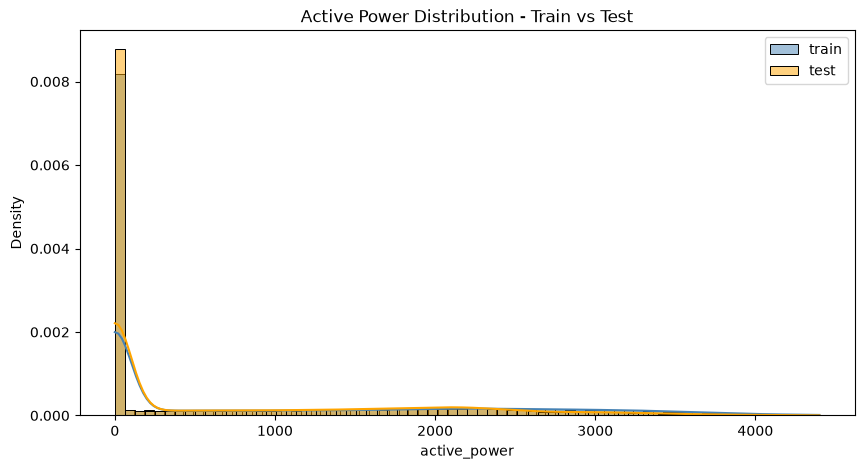

In [58]:
plt.figure(figsize=(10, 5))
plt.title("Active Power Distribution - Train vs Test")
sns.histplot(Y_AC_train, color="steelblue", label="train", kde=True, stat="density")
sns.histplot(Y_AC_test, color="orange", label="test", kde=True, stat="density")
plt.xlabel("active_power")
plt.legend()
plt.show()

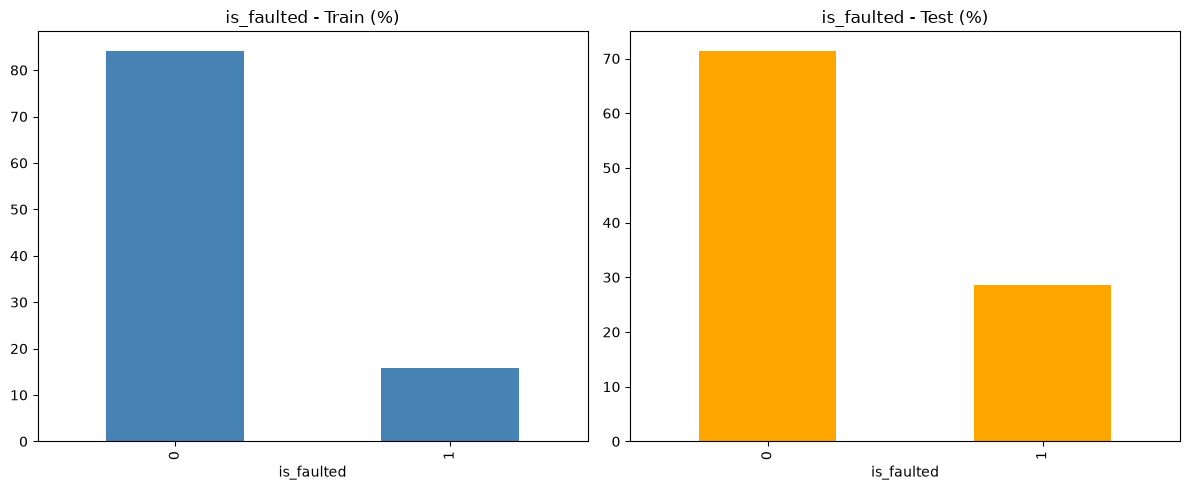

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

Y_is_faulted_train.value_counts(normalize=True).mul(100).plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("is_faulted - Train (%)")

Y_is_faulted_test.value_counts(normalize=True).mul(100).plot(kind="bar", ax=axes[1], color="orange")
axes[1].set_title("is_faulted - Test (%)")

plt.tight_layout()
plt.show()

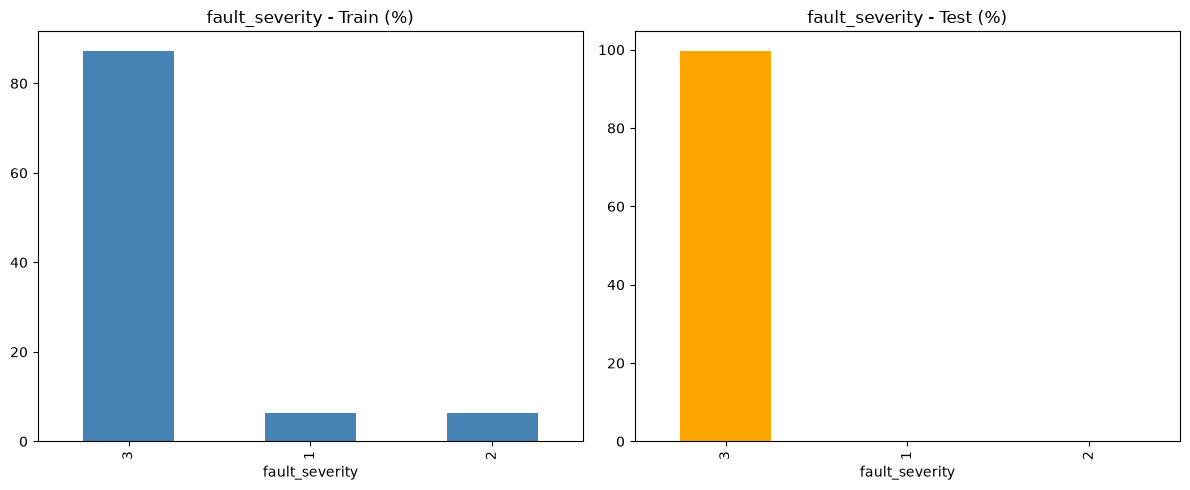

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

Y_severity_train.value_counts(normalize=True).mul(100).plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("fault_severity - Train (%)")

Y_severity_test.value_counts(normalize=True).mul(100).plot(kind="bar", ax=axes[1], color="orange")
axes[1].set_title("fault_severity - Test (%)")

plt.tight_layout()
plt.show()

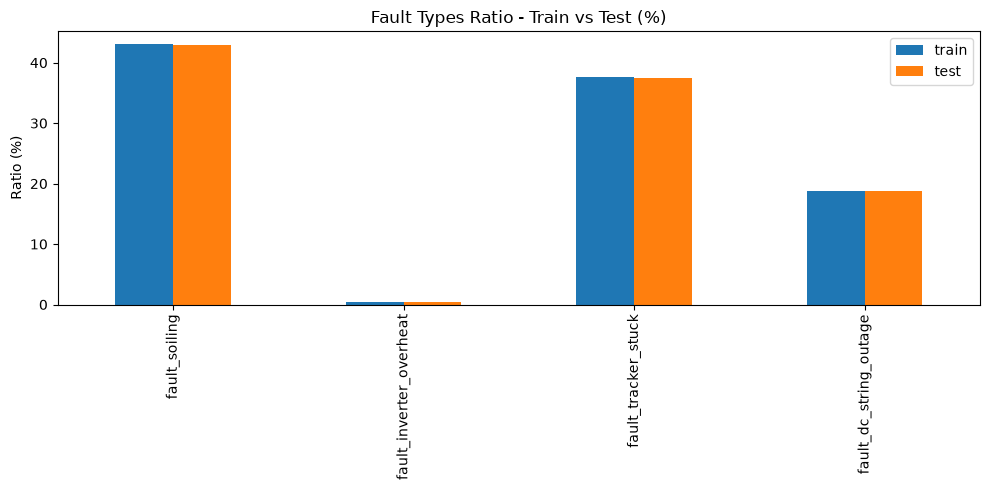

In [61]:
fault_train_ratios = (Y_faults_train.mean() * 100)
fault_test_ratios = (Y_faults_test.mean() * 100)

fault_ratios_compare = pd.DataFrame({"train": fault_train_ratios, "test": fault_test_ratios})
fault_ratios_compare.plot(kind="bar", figsize=(10, 5))
plt.title("Fault Types Ratio - Train vs Test (%)")
plt.ylabel("Ratio (%)")
plt.tight_layout()
plt.show()

## 6. Data-readiness review

A condensed critical review of the data-preparation work above. The full write-up (what went well, the split issue and how it was fixed, the `device`-as-shortcut discussion, and the remaining known limitations) is in the accompanying documentation file.

#### `device` as a feature in the fault-type models

Each fault type in this data maps to exactly one device. The cell below checks how pure that mapping really is (full discussion of why this matters and the decision made is in the external doc).

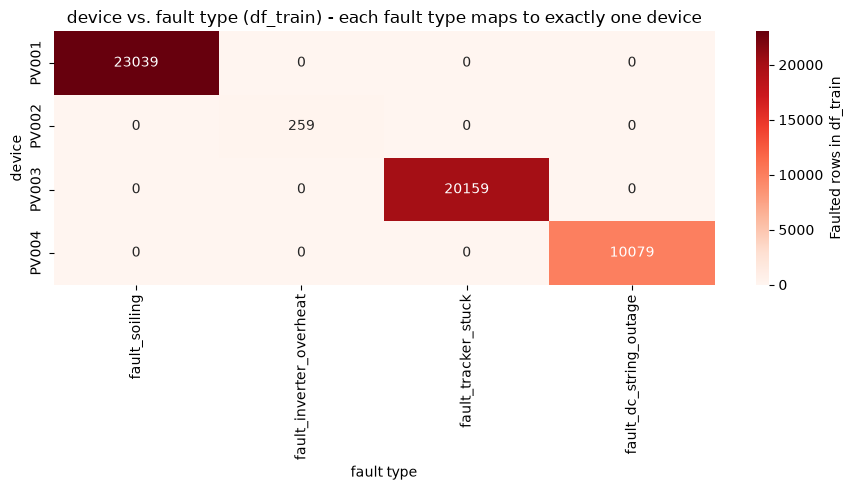

purity per device (%) - share of its top fault type out of all its faulted rows:


device
PV001    100.0
PV002    100.0
PV003    100.0
PV004    100.0
dtype: float64

In [62]:
# Visual check: is every fault type really confined to a single device in df_train?
faulted_train = df_train[df_train['is_faulted'] == 1]
device_vs_faulttype = faulted_train.groupby('device')[fault_targets].sum()

plt.figure(figsize=(9, 5))
sns.heatmap(device_vs_faulttype, annot=True, fmt='d', cmap='Reds',
            cbar_kws={'label': 'Faulted rows in df_train'})
plt.title("device vs. fault type (df_train) - each fault type maps to exactly one device")
plt.xlabel("fault type")
plt.ylabel("device")
plt.tight_layout()
plt.show()

# "Purity": for each device with faults, its top fault type's share of all its faulted rows
purity_pct = device_vs_faulttype.div(device_vs_faulttype.sum(axis=1), axis=0).max(axis=1) * 100
print("purity per device (%) - share of its top fault type out of all its faulted rows:")
purity_pct

Every device is 100% pure for its one fault type - `device_*` (after one-hot encoding) fully determines fault type in this dataset on its own. **Decision:** `device` is kept in X for the fault-type models as-is, documented as a known limitation rather than an unqualified result - see the external doc for the full reasoning and the generalization caveat.

Two more limitations worth visualizing before moving on: how rare `fault_inverter_overheat` is compared to the other fault types, and the class imbalance inside `fault_severity` (see external doc for the full list of remaining notes, including the outlier-code refactor above and the not-yet-used imports).

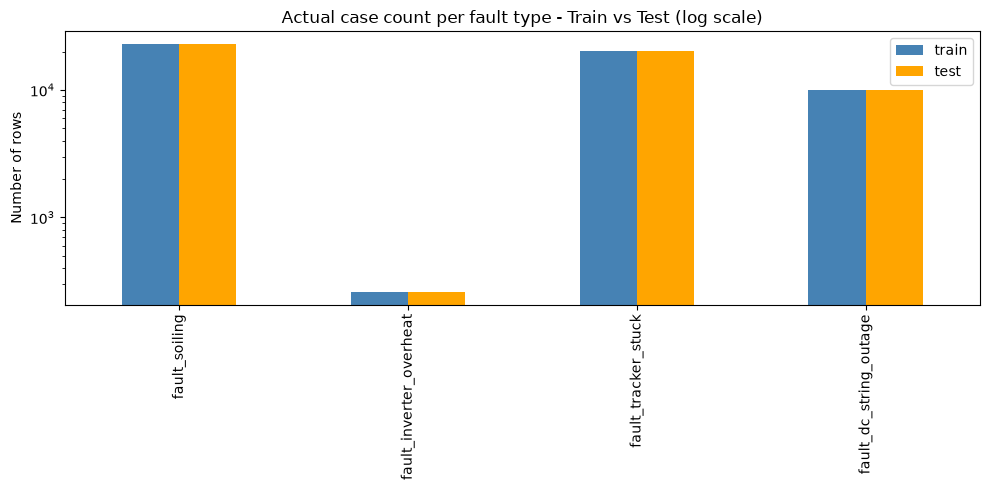

,train,test
fault_soiling,23039,23038
fault_inverter_overheat,259,259
fault_tracker_stuck,20159,20159
fault_dc_string_outage,10079,10079


In [63]:
# fault_inverter_overheat rarity vs. the other fault types (raw counts, not ratios)
fault_counts_train = Y_faults_train.sum()
fault_counts_test = Y_faults_test.sum()

fault_counts_compare = pd.DataFrame({'train': fault_counts_train, 'test': fault_counts_test})
fault_counts_compare.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'orange'])
plt.title("Actual case count per fault type - Train vs Test (log scale)")
plt.ylabel("Number of rows")
plt.yscale('log')
plt.tight_layout()
plt.show()

fault_counts_compare

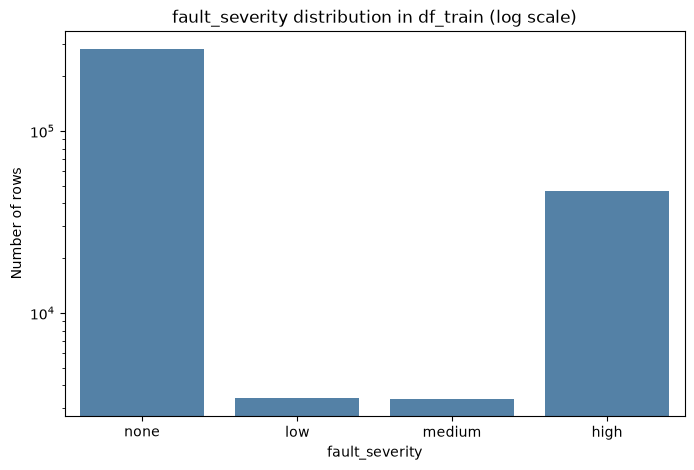

fault_severity
none      284155
low         3428
medium      3389
high       46719
Name: count, dtype: int64

In [64]:
# fault_severity class imbalance (low and medium are much smaller than none/high)
severity_labels = {0: 'none', 1: 'low', 2: 'medium', 3: 'high'}
severity_counts_train = df_train['fault_severity'].map(severity_labels).value_counts().reindex(
    ['none', 'low', 'medium', 'high']
)

plt.figure(figsize=(8, 5))
sns.barplot(x=severity_counts_train.index, y=severity_counts_train.values, color='steelblue')
plt.title("fault_severity distribution in df_train (log scale)")
plt.xlabel("fault_severity")
plt.ylabel("Number of rows")
plt.yscale('log')
plt.show()

severity_counts_train

## 7. Summary

This notebook now covers: full EDA, a per-device profile, a time-gap check, correct encoding for every categorical column, and a single leakage-free chronological split - fixed so every fault type (not just `dc_string_outage`) is represented on both sides - plus class weights ready for every classification target.

The natural next step is training and evaluating the actual models, keeping the review notes from section 6 in mind (especially the `device`-as-feature point). See the external documentation file for the full step-by-step rationale behind every decision made in this notebook.

## Modeling Part

### 1. AC-Power model

first we need to drop features that may make target leakage

This model does not require time-based factors, as it predicts the expected output value for a single day under ideal conditions.

In [65]:
df.columns.tolist()

['device',
 'active_power',
 'irradiance',
 'clear_sky_irradiance',
 'ambient_temp',
 'module_temp',
 'inverter_temp',
 'dc_voltage',
 'dc_current',
 'ac_voltage',
 'ac_current',
 'performance_ratio',
 'cloud_cover',
 'sun_elevation',
 'sun_azimuth',
 'day_length_hours',
 'fault_soiling',
 'fault_inverter_overheat',
 'fault_tracker_stuck',
 'fault_dc_string_outage',
 'is_faulted',
 'fault_labels',
 'fault_severity',
 'hour',
 'month',
 'day_of_week',
 'is_daylight',
 'downtime_duration_min',
 'fault_label_dc_string_outage',
 'fault_label_dc_string_outage|downtime',
 'fault_label_downtime',
 'fault_label_healthy',
 'fault_label_inverter_overheat',
 'fault_label_soiling',
 'fault_label_tracker_stuck',
 'dc_power',
 'ac_power',
 'inverter_efficiency']

In [66]:
leakage_cols = [
    "irradiance",
    "ac_power",
    "active_power",
    "dc_power",
    "ac_voltage",
    "ac_current",
    "performance_ratio",
    "inverter_efficiency",

    "fault_soiling",
    "fault_inverter_overheat",
    "fault_tracker_stuck",
    "fault_dc_string_outage",
    "is_faulted",
    "fault_labels",
    "fault_severity",

    "downtime_duration_min",

    "fault_label_dc_string_outage",
    "fault_label_dc_string_outage|downtime",
    "fault_label_downtime",
    "fault_label_healthy",
    "fault_label_inverter_overheat",
    "fault_label_soiling",
    "fault_label_tracker_stuck",

    "device"
]

X_AC_test = X_AC_test.drop(
    columns=[c for c in leakage_cols if c in X_AC_test.columns]
)

X_AC_train = X_AC_train.drop(
    columns=[c for c in leakage_cols if c in X_AC_train.columns]
)

In [67]:
X_AC_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 284155 entries, 0 to 284154
Data columns (total 31 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   clear_sky_irradiance      284155 non-null  float64
 1   ambient_temp              284155 non-null  float64
 2   module_temp               284155 non-null  float64
 3   inverter_temp             284155 non-null  float64
 4   cloud_cover               284155 non-null  float64
 5   sun_elevation             284155 non-null  float64
 6   sun_azimuth               284155 non-null  float64
 7   day_length_hours          284155 non-null  float64
 8   hour                      284155 non-null  int32  
 9   month                     284155 non-null  int32  
 10  day_of_week               284155 non-null  int32  
 11  is_daylight               284155 non-null  int64  
 12  irradiance_lag1           284155 non-null  float64
 13  irradiance_roll3          284155 non-null  float64
 14 

## view feature importance

Learning rate set to 0.099963
0:	learn: 1131.1697106	total: 191ms	remaining: 3m 11s
1:	learn: 1020.7004620	total: 235ms	remaining: 1m 57s
2:	learn: 921.0405195	total: 286ms	remaining: 1m 35s
3:	learn: 831.7802778	total: 331ms	remaining: 1m 22s
4:	learn: 751.1246886	total: 376ms	remaining: 1m 14s
5:	learn: 678.1123149	total: 425ms	remaining: 1m 10s
6:	learn: 612.7662614	total: 467ms	remaining: 1m 6s
7:	learn: 553.5321993	total: 510ms	remaining: 1m 3s
8:	learn: 499.9067051	total: 556ms	remaining: 1m 1s
9:	learn: 451.7205557	total: 599ms	remaining: 59.3s
10:	learn: 408.3860604	total: 648ms	remaining: 58.3s
11:	learn: 369.3064138	total: 693ms	remaining: 57.1s
12:	learn: 334.0890417	total: 743ms	remaining: 56.4s
13:	learn: 302.5791936	total: 796ms	remaining: 56.1s
14:	learn: 273.9558687	total: 853ms	remaining: 56s
15:	learn: 248.1737228	total: 900ms	remaining: 55.4s
16:	learn: 225.1442052	total: 946ms	remaining: 54.7s
17:	learn: 204.2024677	total: 999ms	remaining: 54.5s
18:	learn: 185.48744

C:\Users\Hp\AppData\Local\Temp\ipykernel_42472\3072455903.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


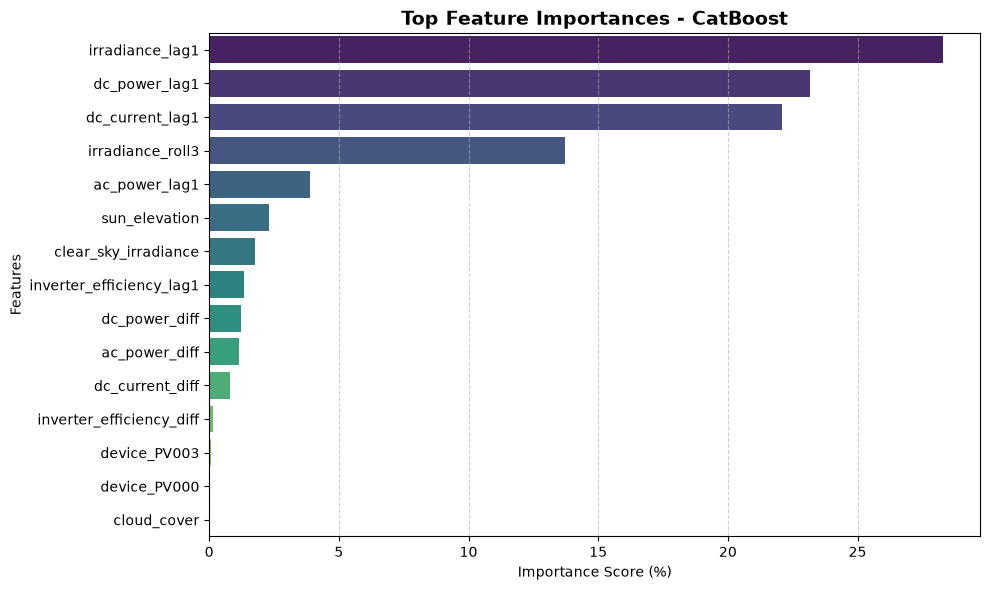

In [68]:
model = CatBoostRegressor(iterations=1000,random_seed=42)
model.fit(X_AC_train,Y_AC_train)

feature_importance = model.get_feature_importance()
importance_df = pd.DataFrame(
    {"Feature": X_AC_train.columns, "Importance": feature_importance}
).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(15),
    palette="viridis",
)

plt.title("Top Feature Importances - CatBoost", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score (%)")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [69]:
X_AC_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 284155 entries, 0 to 284154
Data columns (total 31 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   clear_sky_irradiance      284155 non-null  float64
 1   ambient_temp              284155 non-null  float64
 2   module_temp               284155 non-null  float64
 3   inverter_temp             284155 non-null  float64
 4   cloud_cover               284155 non-null  float64
 5   sun_elevation             284155 non-null  float64
 6   sun_azimuth               284155 non-null  float64
 7   day_length_hours          284155 non-null  float64
 8   hour                      284155 non-null  int32  
 9   month                     284155 non-null  int32  
 10  day_of_week               284155 non-null  int32  
 11  is_daylight               284155 non-null  int64  
 12  irradiance_lag1           284155 non-null  float64
 13  irradiance_roll3          284155 non-null  float64
 14 

In [70]:
AC_Power_model = CatBoostRegressor(iterations=1000,random_seed=42)

AC_Power_model.fit(X_AC_train,Y_AC_train)

Learning rate set to 0.099963
0:	learn: 1131.1697106	total: 55.9ms	remaining: 55.8s
1:	learn: 1020.7004620	total: 115ms	remaining: 57.2s
2:	learn: 921.0405195	total: 172ms	remaining: 57s
3:	learn: 831.7802778	total: 230ms	remaining: 57.3s
4:	learn: 751.1246886	total: 281ms	remaining: 55.9s
5:	learn: 678.1123149	total: 340ms	remaining: 56.3s
6:	learn: 612.7662614	total: 398ms	remaining: 56.5s
7:	learn: 553.5321993	total: 462ms	remaining: 57.3s
8:	learn: 499.9067051	total: 520ms	remaining: 57.2s
9:	learn: 451.7205557	total: 585ms	remaining: 57.9s
10:	learn: 408.3860604	total: 643ms	remaining: 57.8s
11:	learn: 369.3064138	total: 694ms	remaining: 57.2s
12:	learn: 334.0890417	total: 744ms	remaining: 56.5s
13:	learn: 302.5791936	total: 790ms	remaining: 55.7s
14:	learn: 273.9558687	total: 841ms	remaining: 55.3s
15:	learn: 248.1737228	total: 891ms	remaining: 54.8s
16:	learn: 225.1442052	total: 940ms	remaining: 54.4s
17:	learn: 204.2024677	total: 995ms	remaining: 54.3s
18:	learn: 185.4874407	to

CatBoostRegressor(iterations=1000, loss_function='RMSE', random_seed=42)

## evaluating the model

In [71]:
y_pred_AC_train = AC_Power_model.predict(X_AC_train)

mae_train = mean_absolute_error(y_pred_AC_train,Y_AC_train)
r2_train = r2_score(y_pred_AC_train,Y_AC_train)
mse_train = mean_squared_error(y_pred_AC_train,Y_AC_train)

y_pred_AC_test = AC_Power_model.predict(X_AC_test)

mae_test = mean_absolute_error(y_pred_AC_test,Y_AC_test)
r2_test = r2_score(y_pred_AC_test,Y_AC_test)
mse_test = mean_squared_error(y_pred_AC_test,Y_AC_test)

print(f"MSE for train : {mse_train}\n MAE for train : {mae_train}\n R2_score for train : {r2_train}\n MSE for test : {mse_test}\n MAE for test : {mae_test}\n R2_score for test : {r2_test}")


MSE for train : 31.624639299093946
 MAE for train : 3.1134930818031568
 R2_score for train : 0.999979855594392
 MSE for test : 36.40912695886725
 MAE for test : 3.0759837791915605
 R2_score for test : 0.9999683659136512


### 2. is_faulted model

check the importance

Learning rate set to 0.123769
0:	learn: 0.3955246	total: 82.2ms	remaining: 1m 22s
1:	learn: 0.1807748	total: 172ms	remaining: 1m 25s
2:	learn: 0.1216688	total: 261ms	remaining: 1m 26s
3:	learn: 0.0557068	total: 350ms	remaining: 1m 27s
4:	learn: 0.0298791	total: 441ms	remaining: 1m 27s
5:	learn: 0.0233155	total: 525ms	remaining: 1m 27s
6:	learn: 0.0198837	total: 608ms	remaining: 1m 26s
7:	learn: 0.0160232	total: 685ms	remaining: 1m 24s
8:	learn: 0.0135154	total: 778ms	remaining: 1m 25s
9:	learn: 0.0123007	total: 863ms	remaining: 1m 25s
10:	learn: 0.0069548	total: 952ms	remaining: 1m 25s
11:	learn: 0.0066140	total: 1.02s	remaining: 1m 24s
12:	learn: 0.0054600	total: 1.1s	remaining: 1m 23s
13:	learn: 0.0034799	total: 1.19s	remaining: 1m 23s
14:	learn: 0.0033124	total: 1.27s	remaining: 1m 23s
15:	learn: 0.0030845	total: 1.37s	remaining: 1m 24s
16:	learn: 0.0029850	total: 1.52s	remaining: 1m 27s
17:	learn: 0.0020067	total: 1.68s	remaining: 1m 31s
18:	learn: 0.0019513	total: 1.79s	remaining:

C:\Users\Hp\AppData\Local\Temp\ipykernel_42472\1842098245.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


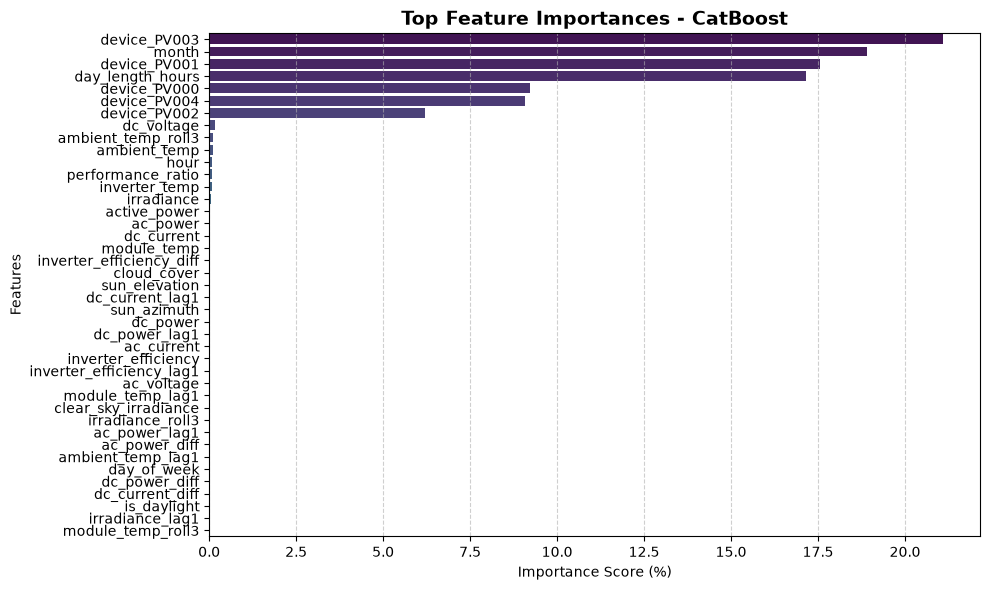

In [72]:
model = CatBoostClassifier(iterations=1000,random_seed=42,auto_class_weights='Balanced')
model.fit(X_is_faulted_train,Y_is_faulted_train)

feature_importance = model.get_feature_importance()
importance_df = pd.DataFrame(
    {"Feature": X_is_faulted_train.columns, "Importance": feature_importance}
).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df,
    palette="viridis",
)

plt.title("Top Feature Importances - CatBoost", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score (%)")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

there is overfitting because model didnt learn Physical factors


In [73]:
metadata_to_drop = [
    "device_PV000",
    "device_PV001",
    "device_PV002",
    "device_PV003",
    "device_PV004",
    "month",
    "day_length_hours",
    "day_of_week",
    "irradiance_roll3",
    "ambient_temp_roll3",
    "module_temp_roll3",
    "hour",
    "is_daylight",
    "sun_azimuth",
    "ac_power_lag1",
    "dc_current_lag1", 
    "ac_voltage", 
    'dc_current_diff', 
    'inverter_efficiency_diff',
    "ac_power_diff",
    "dc_power_diff"
]

X_is_faulted_train = X_is_faulted_train.drop(
    columns=[
        col for col in metadata_to_drop if col in X_is_faulted_train.columns
    ]
)

X_is_faulted_test = X_is_faulted_test.drop(
    columns=[
        col for col in metadata_to_drop if col in X_is_faulted_test.columns
    ]
)

In [74]:
X_is_faulted_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 337691 entries, 0 to 337690
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   active_power              337691 non-null  float64
 1   irradiance                337691 non-null  float64
 2   clear_sky_irradiance      337691 non-null  float64
 3   ambient_temp              337691 non-null  float64
 4   module_temp               337691 non-null  float64
 5   inverter_temp             337691 non-null  float64
 6   dc_voltage                337691 non-null  float64
 7   dc_current                337691 non-null  float64
 8   ac_current                337691 non-null  float64
 9   performance_ratio         337691 non-null  float64
 10  cloud_cover               337691 non-null  float64
 11  sun_elevation             337691 non-null  float64
 12  dc_power                  337691 non-null  float64
 13  ac_power                  337691 non-null  float64
 14 

Learning rate set to 0.197718
0:	learn: 0.5761116	total: 59.4ms	remaining: 35.6s
1:	learn: 0.5379331	total: 173ms	remaining: 51.6s
2:	learn: 0.5099109	total: 237ms	remaining: 47.1s
3:	learn: 0.4843364	total: 338ms	remaining: 50.3s
4:	learn: 0.4695022	total: 455ms	remaining: 54.1s
5:	learn: 0.4555046	total: 519ms	remaining: 51.4s
6:	learn: 0.4451297	total: 588ms	remaining: 49.8s
7:	learn: 0.4332192	total: 658ms	remaining: 48.7s
8:	learn: 0.4217648	total: 724ms	remaining: 47.6s
9:	learn: 0.4140108	total: 790ms	remaining: 46.6s
10:	learn: 0.4059629	total: 861ms	remaining: 46.1s
11:	learn: 0.3967300	total: 928ms	remaining: 45.5s
12:	learn: 0.3847880	total: 1s	remaining: 45.4s
13:	learn: 0.3788598	total: 1.07s	remaining: 45s
14:	learn: 0.3705219	total: 1.14s	remaining: 44.6s
15:	learn: 0.3650247	total: 1.21s	remaining: 44.2s
16:	learn: 0.3591048	total: 1.28s	remaining: 43.9s
17:	learn: 0.3562810	total: 1.34s	remaining: 43.4s
18:	learn: 0.3499619	total: 1.44s	remaining: 44.1s
19:	learn: 0.33

C:\Users\Hp\AppData\Local\Temp\ipykernel_42472\219075522.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


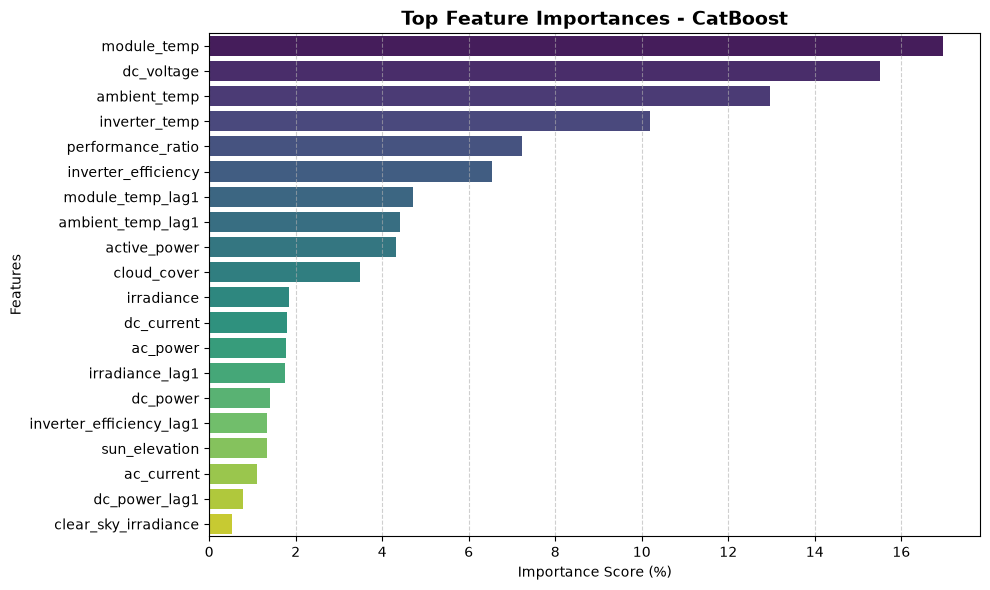

In [75]:
model = CatBoostClassifier(iterations=600,random_seed=42,auto_class_weights='Balanced')
model.fit(X_is_faulted_train,Y_is_faulted_train)

feature_importance = model.get_feature_importance()
importance_df = pd.DataFrame(
    {"Feature": X_is_faulted_train.columns, "Importance": feature_importance}
).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df,
    palette="viridis",
)

plt.title("Top Feature Importances - CatBoost", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score (%)")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [76]:
is_faulted_model = CatBoostClassifier(iterations=1000,random_seed=42,auto_class_weights='Balanced')

is_faulted_model.fit(X_is_faulted_train,Y_is_faulted_train)

Learning rate set to 0.123769
0:	learn: 0.6081997	total: 78.8ms	remaining: 1m 18s
1:	learn: 0.5734981	total: 195ms	remaining: 1m 37s
2:	learn: 0.5442619	total: 269ms	remaining: 1m 29s
3:	learn: 0.5168739	total: 335ms	remaining: 1m 23s
4:	learn: 0.5046320	total: 405ms	remaining: 1m 20s
5:	learn: 0.4898539	total: 473ms	remaining: 1m 18s
6:	learn: 0.4794265	total: 532ms	remaining: 1m 15s
7:	learn: 0.4677701	total: 601ms	remaining: 1m 14s
8:	learn: 0.4592579	total: 666ms	remaining: 1m 13s
9:	learn: 0.4520007	total: 732ms	remaining: 1m 12s
10:	learn: 0.4454180	total: 792ms	remaining: 1m 11s
11:	learn: 0.4317147	total: 865ms	remaining: 1m 11s
12:	learn: 0.4251965	total: 938ms	remaining: 1m 11s
13:	learn: 0.4217970	total: 1.01s	remaining: 1m 11s
14:	learn: 0.4154748	total: 1.08s	remaining: 1m 10s
15:	learn: 0.4082717	total: 1.15s	remaining: 1m 10s
16:	learn: 0.4012167	total: 1.22s	remaining: 1m 10s
17:	learn: 0.3975529	total: 1.28s	remaining: 1m 10s
18:	learn: 0.3924841	total: 1.35s	remaining

CatBoostClassifier(auto_class_weights='Balanced', iterations=1000, random_seed=42)

## evaluation the model

In [77]:
Y_is_faulted_pred = is_faulted_model.predict(X_is_faulted_test)
print(classification_report(Y_is_faulted_test,Y_is_faulted_pred))

              precision    recall  f1-score   support

           0       0.97      0.89      0.93    134153
           1       0.78      0.92      0.85     53736

    accuracy                           0.90    187889
   macro avg       0.87      0.91      0.89    187889
weighted avg       0.91      0.90      0.91    187889



### 3. Fault-Type Classifiers (4 Binary Models)


In [78]:
# CELL 2 — targets + leakage-safe feature list + build X/Y

fault_targets = [
    'fault_soiling',
    'fault_tracker_stuck',
]

fault_extra_drop = [
    # Calendar / time shortcuts — proven leaky (month/day_length_hours drove
    # near-perfect train-only performance that collapsed on the test split)
    'hour',
    'month',
    'day_of_week',
    'is_daylight',
    'day_length_hours',
    'sun_azimuth',   # corr(sun_azimuth, hour) = 0.95 -> smuggles hour back in

    # Power-derived features, dropped out of caution (same family as the
    # features excluded from the AC-power / is_faulted models)
    'ac_power_diff',
    'dc_power_diff',
    'inverter_efficiency',
    'inverter_efficiency_diff',

    # Device identifier — 100% pure predictor of fault type, dropped raw
    # before any one-hot encoding so no device_* dummy can leak back in
    'device'
]

X_faults_train, _ = build_xy(
    df_train,
    target_col='fault_soiling',
    filter_col='is_faulted',
    filter_value=1,
    extra_drop=fault_extra_drop
)

X_faults_test, _ = build_xy(
    df_test,
    target_col='fault_soiling',
    filter_col='is_faulted',
    filter_value=1,
    extra_drop=fault_extra_drop
)

X_faults_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 53536 entries, 0 to 53535
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   clear_sky_irradiance      53536 non-null  float64
 1   ambient_temp              53536 non-null  float64
 2   module_temp               53536 non-null  float64
 3   inverter_temp             53536 non-null  float64
 4   dc_voltage                53536 non-null  float64
 5   dc_current                53536 non-null  float64
 6   cloud_cover               53536 non-null  float64
 7   sun_elevation             53536 non-null  float64
 8   irradiance_lag1           53536 non-null  float64
 9   irradiance_roll3          53536 non-null  float64
 10  ambient_temp_lag1         53536 non-null  float64
 11  ambient_temp_roll3        53536 non-null  float64
 12  module_temp_lag1          53536 non-null  float64
 13  module_temp_roll3         53536 non-null  float64
 14  ac_power_lag1    

In [79]:
# CELL 3 — build Y (multi-label matrix) + per-target class counts

fault_train_mask = df_train['is_faulted'] == 1
fault_test_mask = df_test['is_faulted'] == 1

Y_faults_train = (
    df_train.loc[fault_train_mask, fault_targets]
    .reset_index(drop=True)
)

Y_faults_test = (
    df_test.loc[fault_test_mask, fault_targets]
    .reset_index(drop=True)
)

for target in fault_targets:
    print("=" * 60)
    print(target)
    print(Y_faults_train[target].value_counts())

fault_soiling
fault_soiling
0    30497
1    23039
Name: count, dtype: int64
fault_tracker_stuck
fault_tracker_stuck
0    33377
1    20159
Name: count, dtype: int64


In [80]:
# CELL 4 — train one CatBoost binary classifier per fault type

fault_type_models = {}

for target in fault_targets:
    print(f"Training CatBoost Model for: {target}...")

    model = CatBoostClassifier(
        iterations=800,
        learning_rate=0.05,
        depth=6,
        random_seed=42,
        auto_class_weights='Balanced',
        verbose=0
    )

    model.fit(X_faults_train, Y_faults_train[target])
    fault_type_models[target] = model

print("\nTraining completed!")
print("Models:", list(fault_type_models.keys()))

Training CatBoost Model for: fault_soiling...
Training CatBoost Model for: fault_tracker_stuck...

Training completed!
Models: ['fault_soiling', 'fault_tracker_stuck']


## Feature Importance Visualizations

This plots a 2×2 grid showing the top 10 most influential features for each of the 4 fault types.

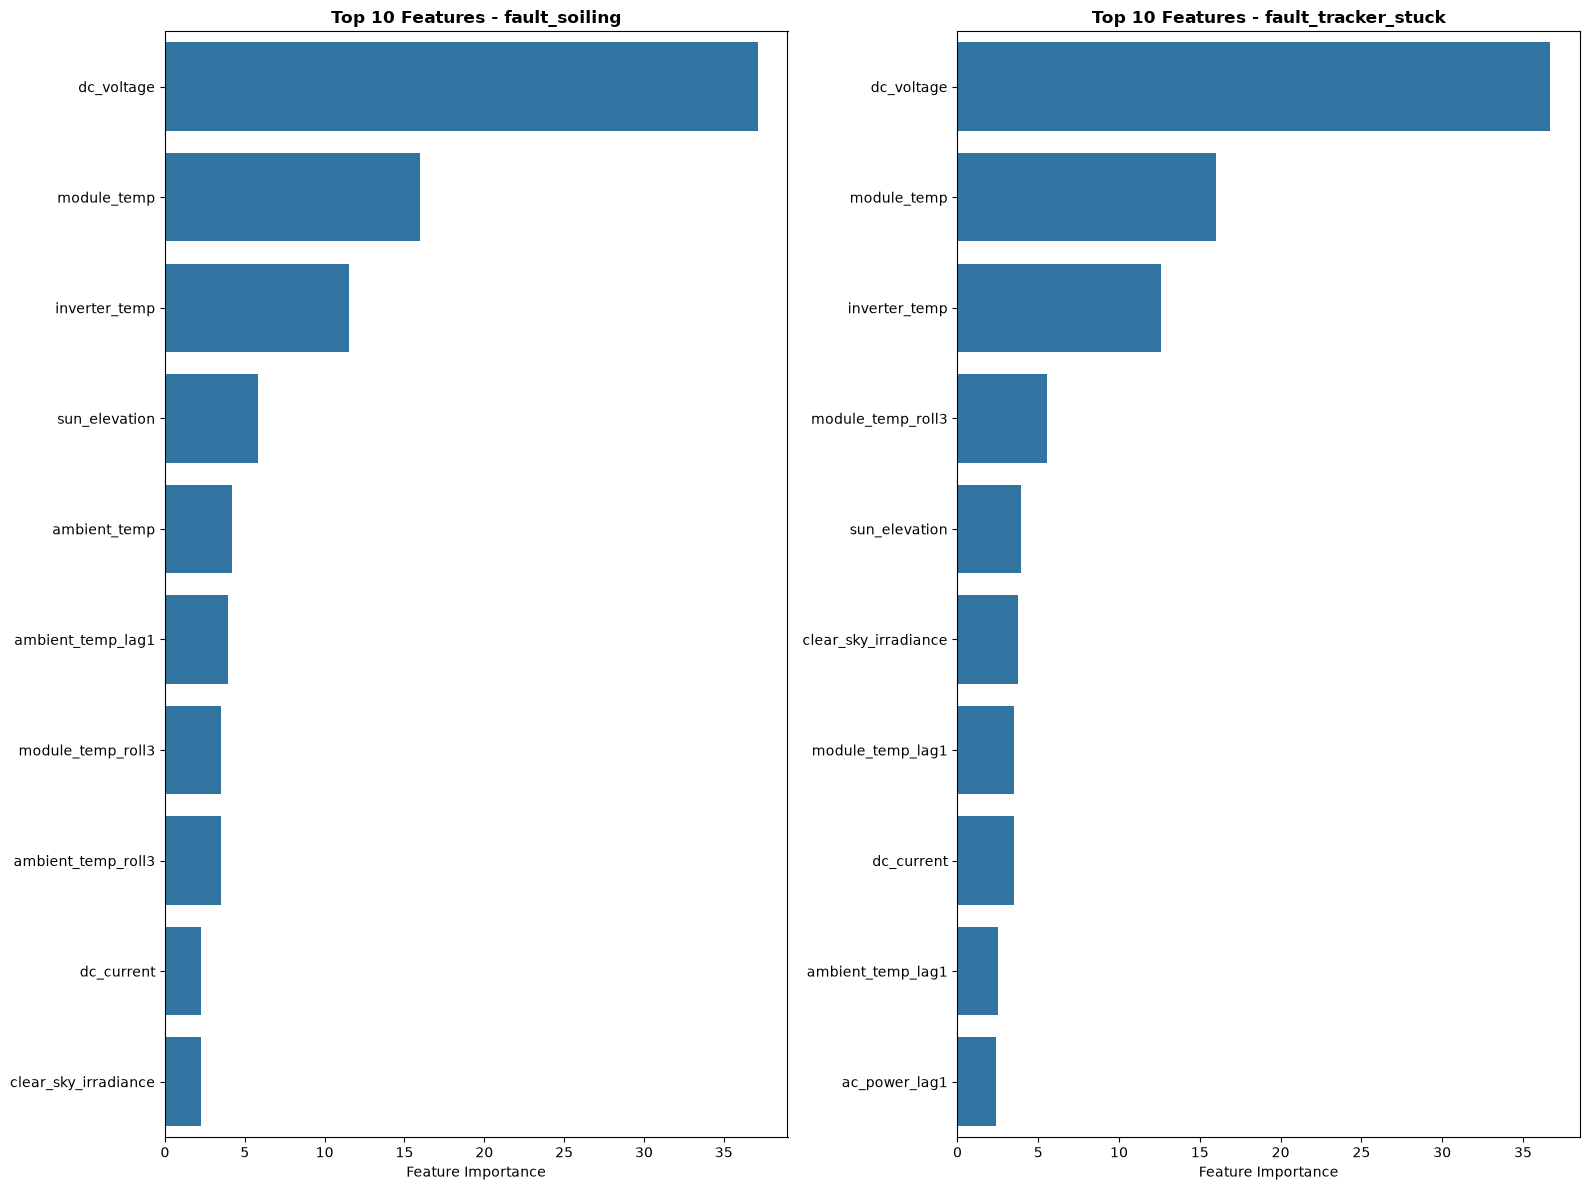

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, target in enumerate(fault_targets):

    model = fault_type_models[target]

    importance = model.get_feature_importance()
    feature_names = model.feature_names_

    imp_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    }).sort_values(
        "Importance",
        ascending=False
    ).head(10)

    sns.barplot(
        data=imp_df,
        x="Importance",
        y="Feature",
        ax=axes[idx]
    )

    axes[idx].set_title(
        f"Top 10 Features - {target}",
        fontweight="bold"
    )

    axes[idx].set_xlabel("Feature Importance")
    axes[idx].set_ylabel("")

plt.tight_layout()
plt.show()

## Evaluation of Fault-Type Models

In [82]:

for target in fault_targets:

    model = fault_type_models[target]

    y_true = Y_faults_test[target]
    y_pred = model.predict(X_faults_test)

    print("=" * 70)
    print(f"CLASSIFICATION REPORT: {target}")
    print("=" * 70)

    print(
        classification_report(
            y_true,
            y_pred,
            digits=4
        )
    )

CLASSIFICATION REPORT: fault_soiling
              precision    recall  f1-score   support

           0     0.9527    0.8064    0.8735     30698
           1     0.7858    0.9466    0.8588     23038

    accuracy                         0.8665     53736
   macro avg     0.8693    0.8765    0.8661     53736
weighted avg     0.8811    0.8665    0.8672     53736

CLASSIFICATION REPORT: fault_tracker_stuck
              precision    recall  f1-score   support

           0     0.8515    0.9585    0.9019     33577
           1     0.9127    0.7216    0.8059     20159

    accuracy                         0.8696     53736
   macro avg     0.8821    0.8401    0.8539     53736
weighted avg     0.8744    0.8696    0.8659     53736



Summary


In [83]:
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score   # <- accuracy_score added
)
results = []

# ---- 1. AC Power model (Regression) ----
y_pred_AC_test = AC_Power_model.predict(X_AC_test)

results.append({
    "Model": "AC Power (Regression)",
    "Type": "Regression",
    "Accuracy": np.nan,
    "Precision": np.nan,
    "Recall": np.nan,
    "F1": np.nan,
    "R2": r2_score(Y_AC_test, y_pred_AC_test),
    "MAE": mean_absolute_error(Y_AC_test, y_pred_AC_test),
    "RMSE": np.sqrt(mean_squared_error(Y_AC_test, y_pred_AC_test))
})

# ---- 2. is_faulted model (Binary Classification) ----
Y_is_faulted_pred = is_faulted_model.predict(X_is_faulted_test)

results.append({
    "Model": "is_faulted (Classification)",
    "Type": "Classification",
    "Accuracy": accuracy_score(Y_is_faulted_test, Y_is_faulted_pred),
    "Precision": precision_score(Y_is_faulted_test, Y_is_faulted_pred, pos_label=1),
    "Recall": recall_score(Y_is_faulted_test, Y_is_faulted_pred, pos_label=1),
    "F1": f1_score(Y_is_faulted_test, Y_is_faulted_pred, pos_label=1),
    "R2": np.nan,
    "MAE": np.nan,
    "RMSE": np.nan
})

# ---- 3. Fault-type models (4 Binary Classifiers) ----
for target in fault_targets:
    model = fault_type_models[target]
    y_true = Y_faults_test[target]
    y_pred = model.predict(X_faults_test).ravel()

    results.append({
        "Model": target,
        "Type": "Classification",
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=1),
        "Recall": recall_score(y_true, y_pred, pos_label=1),
        "F1": f1_score(y_true, y_pred, pos_label=1),
        "R2": np.nan,
        "MAE": np.nan,
        "RMSE": np.nan
    })

# ---- Build final table ----
summary_df = pd.DataFrame(results)

numeric_cols = ["Accuracy", "Precision", "Recall", "F1", "R2", "MAE", "RMSE"]
summary_df[numeric_cols] = summary_df[numeric_cols].round(4)

print("=" * 90)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 90)
summary_df

MODEL PERFORMANCE SUMMARY


,Model,Type,Accuracy,Precision,Recall,F1,R2,MAE,RMSE
0,AC Power (Regression),Regression,NaN,NaN,NaN,NaN,1.0,3.076,6.034
1,is_faulted (Classification),Classification,0.9030,0.7782,0.9244,0.8450,NaN,NaN,NaN
2,fault_soiling,Classification,0.8665,0.7858,0.9466,0.8588,NaN,NaN,NaN
3,fault_tracker_stuck,Classification,0.8696,0.9127,0.7216,0.8059,NaN,NaN,NaN


In [84]:
# ============================================================
# RUN THIS AS A CELL AT THE END OF YOUR NOTEBOOK
# It creates a "deployment_artifacts" folder containing everything
# the Streamlit app needs: the trained models + feature metadata.
# ============================================================

import os, json

os.makedirs("deployment_artifacts", exist_ok=True)

# 1. Save all 6 models (CatBoost's native format, no pickle needed)
AC_Power_model.save_model("deployment_artifacts/ac_power_model.cbm")
is_faulted_model.save_model("deployment_artifacts/is_faulted_model.cbm")

for target in fault_targets:
    fault_type_models[target].save_model(f"deployment_artifacts/{target}_model.cbm")

# 2. Save the exact feature list + column order each model expects
#    (CatBoost is order-sensitive at predict time)
feature_lists = {
    "ac_power_features": list(X_AC_train.columns),
    "is_faulted_features": list(X_is_faulted_train.columns),
    "fault_type_features": list(X_faults_train.columns),
}
with open("deployment_artifacts/feature_lists.json", "w") as f:
    json.dump(feature_lists, f, indent=2)

# 3. Save min/mean/max for every feature used by any model, so the
#    Streamlit form can build sensible number_input ranges/defaults.
#    Any feature NOT found directly in df_train (e.g. a lag/roll/diff
#    column) gets flagged so you know it needs manual entry in the app.
all_features = set(
    feature_lists["ac_power_features"]
    + feature_lists["is_faulted_features"]
    + feature_lists["fault_type_features"]
)

feature_stats = {}
for col in all_features:
    if col in df_train.columns:
        feature_stats[col] = {
            "min": float(df_train[col].min()),
            "max": float(df_train[col].max()),
            "mean": float(df_train[col].mean()),
        }
    else:
        # Not a raw column -> likely lag/roll/diff/one-hot. Give a
        # generic numeric range so the form still works; the user
        # will just type the value in directly.
        feature_stats[col] = {"min": -100.0, "max": 1000.0, "mean": 0.0}

with open("deployment_artifacts/feature_stats.json", "w") as f:
    json.dump(feature_stats, f, indent=2)

print("Done. Files created in ./deployment_artifacts/:")
for fname in sorted(os.listdir("deployment_artifacts")):
    print(" -", fname)

print("\nZip this folder and keep it alongside app.py in your GitHub repo.")


Done. Files created in ./deployment_artifacts/:
 - ac_power_model.cbm
 - fault_soiling_model.cbm
 - fault_tracker_stuck_model.cbm
 - feature_lists.json
 - feature_stats.json
 - is_faulted_model.cbm

Zip this folder and keep it alongside app.py in your GitHub repo.
